# JSON utilities

In [16]:
from __future__ import annotations
import base64, json, os, tempfile
from pathlib import Path
from typing import Dict, Any, Callable, Optional, MutableMapping
from collections import defaultdict

# Optional numpy import
try:
    import numpy as np  # type: ignore
except Exception:
    np = None  # falls back gracefully if numpy isn't available

PATH: Optional[Path] = None

def _ensure_path(path: Optional[Path]) -> Path:
    if path is None:
        raise ValueError("A valid path must be provided (PATH is None).")
    return path

def _encode_key(k: Any) -> str:
    if isinstance(k, str):
        return k
    if isinstance(k, bytes):
        try:
            return k.decode("utf-8")
        except UnicodeDecodeError:
            import base64 as _b64
            return "b64:" + _b64.b64encode(k).decode("ascii")
    return str(k)

def _to_plain_jsonable(obj: Any) -> Any:
    """
    Recursively convert to JSON-serializable types:
    - dict/defaultdict -> dict with string keys
    - list/tuple/set -> list
    - pathlib.Path -> str
    - numpy ndarray -> list; numpy scalar -> Python scalar
    - primitives (str/int/float/bool/None) unchanged
    """
    # NumPy arrays & scalars
    if np is not None:
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        # includes np.int64, np.float64, np.bool_, and other np.generic scalars
        if isinstance(obj, (np.generic,)):
            return obj.item()

    if isinstance(obj, dict):
        return { _encode_key(k): _to_plain_jsonable(v) for k, v in obj.items() }

    if isinstance(obj, (list, tuple, set)):
        return [ _to_plain_jsonable(v) for v in obj ]

    if isinstance(obj, Path):
        return str(obj)

    if isinstance(obj, bytes):
        try:
            return obj.decode("utf-8")
        except UnicodeDecodeError:
            return "b64:" + base64.b64encode(obj).decode("ascii")

    return obj  # primitives

def _wrap_default(d: Dict[str, Any],
                  default_factory: Optional[Callable[[], Any]]) -> MutableMapping[str, Any]:
    return defaultdict(default_factory, d) if default_factory is not None else d

def load_dict(
    path: Optional[Path] = PATH,
    *,
    default_factory: Optional[Callable[[], Any]] = None,
) -> MutableMapping[str, Any]:
    path = _ensure_path(path)
    if not path.exists():
        return _wrap_default({}, default_factory)
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise ValueError("JSON root must be an object (dict-like).")
    return _wrap_default(data, default_factory)

def save_dict(
    d: MutableMapping[str, Any],
    path: Optional[Path] = PATH,
) -> None:
    path = _ensure_path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fd, tmp_name = tempfile.mkstemp(prefix=path.name + ".", dir=str(path.parent))
    try:
        with os.fdopen(fd, "w", encoding="utf-8") as f:
            json.dump(_to_plain_jsonable(d), f, indent=2, sort_keys=True, ensure_ascii=False)
            f.write("\n")
        os.replace(tmp_name, path)
    except Exception:
        try:
            os.unlink(tmp_name)
        except OSError:
            pass
        raise

def update_dict(
    updates: Dict[str, Any],
    path: Optional[Path] = PATH,
    *,
    default_factory: Optional[Callable[[], Any]] = None,
) -> MutableMapping[str, Any]:
    d = load_dict(path, default_factory=default_factory)
    d.update(updates)
    save_dict(d, path)
    return d

In [17]:
# Pick a file
PATH = Path("state.json")

# defaultdict(int): missing keys default to 0
d2 = load_dict(PATH, default_factory=int)
d2["shit"] += 1                   # works even if 'count' wasn't present
save_dict(d2, PATH)

# Graph utilities

In [15]:
import numpy as np
import scipy.sparse as sp

# pip install networkx numpy
import networkx as nx
from typing import List, Tuple, Dict

from itertools import product

def _edges_from_str_pairs(pairs: List[str], one_based=True) -> List[Tuple[int,int]]:
    """
    Convert compact edge notation like ["12","13","58"] to list of (u,v) tuples.
    If one_based=True, vertices are 1..8; otherwise 0..7.
    """
    edges = []
    for s in pairs:
        if len(s) != 2 or not s.isdigit():
            raise ValueError(f"Bad edge code: {s!r}")
        u, v = int(s[0]), int(s[1])
        if not one_based:
            u -= 1; v -= 1
        if u == v:
            raise ValueError(f"Loop edge not allowed: {s}")
        edges.append((u, v) if u < v else (v, u))
    return sorted(set(edges))

def cubic_graphs_n8_from_lists(
    zero_based: bool = False,
    want_matrices: bool = True,
    check_connected: bool = False,
) -> Dict[str, Dict[str, object]]:
    """
    Build the 6 non-isomorphic 3-regular graphs on 8 vertices using provided edge-lists.

    Parameters
    ----------
    zero_based : bool
        If True, relabel vertices to 0..7 in outputs; otherwise keep 1..8.
    want_matrices : bool
        If True, include 8x8 numpy adjacency matrices in the result.
    check_connected : bool
        If True, assert which graphs are connected.

    Returns
    -------
    dict
        keys: "Graph 1".."Graph 6"
        values: dict with fields:
            - "edges": list[(u,v)]
            - "G": networkx.Graph
            - "A": np.ndarray (8x8) if want_matrices=True
            - "notes": str (for known named graphs)
    """
    # Your 6 edge-lists (one-based labels)
    raw = {
        "Graph 1": ["12","13","14","23","24","34","56","57","58","67","68","78"],
        "Graph 2": ["12","13","14","24","34","26","37","56","57","58","68","78"],
        "Graph 3": ["12","13","23","14","47","25","58","36","45","67","68","78"],
        "Graph 4": ["12","13","23","14","25","36","47","48","57","58","67","68"],
        "Graph 5": ["12","13","24","34","15","26","37","48","56","57","68","78"],
        "Graph 6": ["12","23","34","45","56","67","78","18","15","26","37","48"],
    }

    # Known names for three of them
    notes = {
        "Graph 1": "K4 ⊔ K4 (disconnected)",
        "Graph 5": "Cube graph Q3 (a.k.a. 4-prism C4 □ K2)",
        "Graph 6": "Möbius/Wagner graph M8 (C8 + opposite chords)",
    }

    result = {}
    for name, pair_list in raw.items():
        edges = _edges_from_str_pairs(pair_list, one_based=True)

        # Build graph with 1..8 nodes
        G = nx.Graph()
        G.add_nodes_from(range(1, 9))
        G.add_edges_from(edges)

        # Sanity: 3-regular?
        degs = [d for _, d in G.degree()]
        assert all(d == 3 for d in degs), f"{name} is not 3-regular: degrees={degs}"

        if check_connected:
            # Expect all except Graph 1 to be connected
            if name == "Graph 1":
                assert not nx.is_connected(G), f"{name} should be disconnected"
            else:
                assert nx.is_connected(G), f"{name} should be connected"

        # Optional relabel 0..7
        if zero_based:
            mapping = {i: i-1 for i in range(1, 9)}
            G = nx.relabel_nodes(G, mapping)
            edges_ob = sorted((min(u, v), max(u, v)) for (u, v) in G.edges())
            nodes = list(range(8))
        else:
            edges_ob = edges
            nodes = list(range(1, 9))

        entry = {
            "edges": edges_ob,
            "G": G,
            "notes": notes.get(name, ""),
        }

        if want_matrices:
            A = nx.to_numpy_array(G, nodelist=nodes, dtype=int)
            entry["A"] = A

        result[name] = entry

    return result

def band_matrix_n_qubits(n, bandwidth, periodic=False, sparse=False):
    """
    Hermitian band matrix on n qubits (size d=2**n).
    - Diagonal is always zero.
    - Off-diagonals within |i-j|<=bandwidth are 1.
    - If periodic=True, wrap-around distance is used.
    """
    d = 1 << n
    w = max(0, min(int(bandwidth), d-1))
    if w == 0:
        return sp.csr_matrix((d, d)) if (sparse and sp) else np.zeros((d, d), float)

    if sparse and sp is not None:
        diags = []
        offs  = []
        # non-periodic band: offsets ±1..±w
        for k in range(1, w+1):
            diags += [np.ones(d-k), np.ones(d-k)]
            offs  += [ k, -k]
        # periodic wrap: offsets ±(d-k)
        if periodic:
            for k in range(1, w+1):
                diags += [np.ones(k), np.ones(k)]
                offs  += [ d-k, k-d]
        A = sp.diags(diags, offs, shape=(d, d), format="csr")
        A.setdiag(0)  # ensure zero diagonal
        return A
    else:
        if periodic:
            # circulant band: min(|i-j|, d-|i-j|) <= w
            idx = np.arange(d)
            A = np.zeros((d, d), float)
            for k in range(1, w+1):
                A[idx, (idx+k) % d] = 1
                A[idx, (idx-k) % d] = 1
        else:
            A = np.zeros((d, d), float)
            for k in range(1, w+1):
                A[np.arange(d-k), np.arange(k, d)] = 1
                A[np.arange(k, d), np.arange(d-k)] = 1
        np.fill_diagonal(A, 0)
        return A

# Dense (NumPy) and Sparse (SciPy) adjacency for the n-dimensional hypercube Q_n
import numpy as np

def hypercube_adjacency_dense(n: int, dtype=int) -> np.ndarray:
    """
    Return the 2^n x 2^n dense adjacency matrix of the n-dimensional hypercube Q_n.
    Vertex i (0..2^n-1) is connected to i^ (1<<b) for each bit b in [0, n).
    """
    if n < 0:
        raise ValueError("n must be >= 0")
    N = 1 << n  # number of vertices
    A = np.zeros((N, N), dtype=dtype)
    for i in range(N):
        for b in range(n):
            j = i ^ (1 << b)  # flip bit b
            A[i, j] = 1
            A[j, i] = 1
    return A


# Optional: faster & memory-friendly sparse version
from scipy.sparse import coo_matrix, csr_matrix

def hypercube_adjacency_sparse(n: int) -> csr_matrix:
    """
    Return the 2^n x 2^n CSR sparse adjacency matrix of Q_n.
    """
    if n < 0:
        raise ValueError("n must be >= 0")
    N = 1 << n
    rows, cols = [], []
    for i in range(N):
        for b in range(n):
            j = i ^ (1 << b)
            rows.append(i); cols.append(j)
            rows.append(j); cols.append(i)  # add symmetric entry
    data = np.ones(len(rows), dtype=int)
    return coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()

def random_graph(
    n=None,
    p=None,
    d=None,
    degree_sequence=None,
    *,
    seed=None,
    simple=True,
    allow_self_loops=False,
    return_matrix=True,
    max_tries=10_000,
):
    """
    One-stop random graph generator.

    Modes (auto-detected by provided args):
      • G(n,p):            provide n and p
      • d-regular:         provide n and d
      • fixed degree seq:  provide degree_sequence (list of ints)

    Args:
      n: number of nodes (0..n-1). Required for G(n,p) and d-regular.
      p: edge probability (G(n,p)).
      d: degree per node (d-regular).
      degree_sequence: exact degrees per node (len = n if n given, else inferred).
      seed: RNG seed (int or None).
      simple: enforce simple graph (no multi-edges; and no self-loops unless allow_self_loops=True).
      allow_self_loops: allow u==v edges (ignored for G(n,p) which already avoids them).
      return_matrix: return adjacency matrix instead of edge list.
      max_tries: max rejection attempts for simple configuration-model sampling.

    Returns:
      Edge list [(u,v), ...] with u<v if simple, else arbitrary pairs; or adjacency matrix if return_matrix=True.
    """
    import random
    rng = random.Random(seed)

    # ---------------- helpers (scoped) ----------------
    def to_adj_matrix(edges, nn):
        A = [[0]*nn for _ in range(nn)]
        for u, v in edges:
            A[u][v] += 1
            A[v][u] += 1
        return np.array(A)

    def check_simple(edges, nn, allow_loops):
        if not allow_loops:
            for u, v in edges:
                if u == v:
                    return False
        seen = set()
        for u, v in edges:
            a, b = (u, v) if u <= v else (v, u)
            if (a, b) in seen:
                return False
            seen.add((a, b))
        return True

    def erdos_gallai(deg):
        d_sorted = sorted(deg, reverse=True)
        if any(x < 0 for x in d_sorted): return False
        if sum(d_sorted) % 2: return False
        pref = [0]
        for x in d_sorted: pref.append(pref[-1]+x)
        m = len(d_sorted)
        for k in range(1, m+1):
            left = pref[k]
            right = k*(k-1) + sum(min(x, k) for x in d_sorted[k:])
            if left > right: return False
        return True

    def config_model(deg, nn):
        if any(dv < 0 for dv in deg):
            raise ValueError("Degrees must be nonnegative.")
        if sum(deg) % 2 != 0:
            raise ValueError("Sum of degrees must be even.")
        stubs_template = []
        for v, dv in enumerate(deg):
            stubs_template.extend([v]*dv)
        for _ in range(max_tries):
            stubs = stubs_template[:]
            rng.shuffle(stubs)
            edges = [(stubs[i], stubs[i+1]) for i in range(0, len(stubs), 2)]
            if simple:
                if not check_simple(edges, nn, allow_self_loops):
                    continue
                # normalize pairs to u<v if simple
                edges = [(u, v) if u < v else (v, u) for u, v in edges]
                # deduplicate (should be none if truly simple)
                edges = list(dict.fromkeys(edges))
            return edges
        raise RuntimeError("Failed to sample a simple graph with the given degree data (increase max_tries or relax constraints).")

    # ---------------- mode selection ----------------
    mode = None
    if degree_sequence is not None:
        deg = list(degree_sequence)
        nn = len(deg) if n is None else n
        if n is not None and len(deg) != n:
            raise ValueError("len(degree_sequence) must equal n when n is provided.")
        if simple and not erdos_gallai(deg):
            raise ValueError("Degree sequence is not graphical (Erdős–Gallai failed) with simple=True.")
        mode = "degree_sequence"
    elif d is not None:
        if n is None:
            raise ValueError("n is required for d-regular graphs.")
        if d < 0:
            raise ValueError("d must be >= 0.")
        if simple and d >= n:
            raise ValueError("For simple graphs, require d < n.")
        if (n * d) % 2 != 0:
            raise ValueError("n*d must be even.")
        deg = [d]*n
        nn = n
        mode = "d_regular"
    elif (n is not None) and (p is not None):
        if not (0.0 <= p <= 1.0):
            raise ValueError("p must be in [0,1].")
        nn = n
        mode = "gnp"
    else:
        raise ValueError("Ambiguous inputs. Provide either (n,p) OR (n,d) OR degree_sequence.")

    # ---------------- sampling ----------------
    if mode in ("degree_sequence", "d_regular"):
        edges = config_model(deg, nn)
    else:  # G(n,p)
        edges = []
        for u in range(nn):
            for v in range(u+1, nn):
                if rng.random() < p:
                    edges.append((u, v))

    return to_adj_matrix(edges, nn) if return_matrix else edges

def lattice_adjacency(shape, periodic=False, gray_permute=False, return_perm=False):
    """
    Generate the adjacency matrix of a D-dimensional lattice graph.

    Parameters
    ----------
    shape : tuple of ints
        Number of sites per dimension, e.g. (3,3,3) for a 3x3x3 lattice.
    periodic : bool, optional
        If True, use periodic boundary conditions along each dimension.
        If False, use open boundary conditions. Default is False.
    gray_permute : bool, optional
        If True, permute rows and columns so that along each dimension
        coordinate index i is mapped to its Gray code index i' = i ^ (i >> 1).
        Requires each shape[d] to be a power of 2.
    return_perm : bool, optional
        If True, also return the permutation array `perm` such that
        A_gray = A[np.ix_(perm, perm)].

    Returns
    -------
    A : np.ndarray, shape (N, N)
        Adjacency matrix, where N = prod(shape).
    perm : np.ndarray, shape (N,), optional
        The permutation used for Gray ordering (only if return_perm=True).
    """
    shape = tuple(shape)
    dims = len(shape)
    N = int(np.prod(shape))
    A = np.zeros((N, N), dtype=int)

    # Map D-dimensional coordinate -> single index in [0, N)
    def coord_to_index(coord):
        idx = 0
        stride = 1
        # row-major: last dimension changes fastest
        for d in reversed(range(dims)):
            idx += coord[d] * stride
            stride *= shape[d]
        return idx

    # Build adjacency in the standard (lexicographic) ordering
    for coord in product(*[range(s) for s in shape]):
        i = coord_to_index(coord)

        for d in range(dims):
            for delta in (-1, 1):
                neighbor = list(coord)
                neighbor[d] += delta

                # Handle boundaries
                if periodic:
                    neighbor[d] %= shape[d]
                else:
                    if not (0 <= neighbor[d] < shape[d]):
                        continue

                j = coord_to_index(tuple(neighbor))
                A[i, j] = 1
                A[j, i] = 1  # ensure symmetry

    # Optionally permute using per-dimension Gray coding
    if gray_permute:
        # require each dimension length to be a power of 2
        for s in shape:
            if s & (s - 1) != 0:
                raise ValueError(
                    f"Gray permutation requires each dimension size to be a power of 2, "
                    f"but got shape={shape}."
                )

        def gray(i):
            return i ^ (i >> 1)

        perm = np.empty(N, dtype=int)

        # For each coordinate in standard order, map to Gray-coded coordinate
        for coord in product(*[range(s) for s in shape]):
            idx = coord_to_index(coord)
            gray_coord = tuple(gray(c) for c in coord)
            idx_gray = coord_to_index(gray_coord)
            perm[idx] = idx_gray

        # Apply permutation: A' = P A P^T
        A = A[np.ix_(perm, perm)]

        if return_perm:
            return A, perm
        else:
            return A

    # No Gray permutation
    if return_perm:
        perm = np.arange(N, dtype=int)
        return A, perm
    else:
        return A

# Example usage:
shape = (4, 4)  # 2D 4x4 lattice, each dimension has 2^2 sites
A_standard = lattice_adjacency(shape, periodic=False, gray_permute=False)
A_gray, perm = lattice_adjacency(shape, periodic=False, gray_permute=True, return_perm=True)

print("Standard adjacency shape:", A_standard.shape)
print("Gray-ordered adjacency shape:", A_gray.shape)
print("Permutation:", perm)


# Example usage
if __name__ == "__main__":
    # Example usage:
    shape = (8,)  # 3x3x3 lattice
    A = lattice_adjacency(shape, periodic=False, gray_permute=True)
    print(A.shape)  # (27, 27)
    print(A)

Standard adjacency shape: (16, 16)
Gray-ordered adjacency shape: (16, 16)
Permutation: [ 0  1  3  2  4  5  7  6 12 13 15 14  8  9 11 10]
(8, 8)
[[0 1 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 1]
 [0 1 1 0 0 0 0 0]
 [0 0 0 0 0 1 1 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 1]
 [0 0 1 0 0 0 1 0]]


# Pauli utilities

In [18]:
from itertools import combinations, product
from math import comb

PAULI_NON_I = ("X", "Y", "Z")

def generate_pauli_labels(n: int, k: int):
    """
    Yield all n-qubit Pauli *labels* (over {I,X,Y,Z}) with Hamming weight > k.
    Weight = number of non-I factors. No ±1, ±i phases included.
    """
    if k < -1:
        k = -1
    if k >= n:
        return
    I_row = ["I"] * n
    for w in range(k + 1, n + 1):
        for pos in combinations(range(n), w):
            # fill chosen positions with any of {X,Y,Z}
            for non_i_choices in product(PAULI_NON_I, repeat=w):
                row = I_row[:]              # start with all I
                for p, s in zip(pos, non_i_choices):
                    row[p] = s
                yield "".join(row)

# --- Optional: as matrices (dense 2^n x 2^n) ---------------------------------
# Only use if you truly need full matrices; otherwise labels are far cheaper.

import numpy as np

_single_qubit = {
    "I": np.array([[1, 0],[0, 1]], dtype=complex),
    "X": np.array([[0, 1],[1, 0]], dtype=complex),
    "Y": np.array([[0, -1j],[1j, 0]], dtype=complex),
    "Z": np.array([[1, 0],[0,-1]], dtype=complex),
}

def label_to_matrix(label: str) -> np.ndarray:
    """Tensor-product the single-qubit Paulis according to the label string."""
    M = _single_qubit[label[0]]
    for ch in label[1:]:
        M = np.kron(M, _single_qubit[ch])
    return M

def generate_pauli_matrices(n: int, k: int):
    """Yield (label, matrix) for all weight>k operators (dense matrices)."""
    for label in generate_pauli_labels(n, k):
        yield label, label_to_matrix(label)

# --- Quick sanity check: count matches sum_{w=k+1}^n C(n,w) * 3^w -------------
def count_expected(n, k):
    return sum(comb(n, w) * (3 ** w) for w in range(k + 1, n + 1))

def Pauli_coeff_sum(H, n, k):
    S = 0
    for (i, (Pauli_i_label, Pauli_i)) in enumerate(generate_pauli_matrices(n, k)):
        #print(Pauli_i_label, np.trace(H @ Pauli_i))
        S += np.trace(H @ Pauli_i)
    return S         

def Pauli_coeff_abs_sum(H, n, k, weighted=True):
    S = 0
    for (i, (Pauli_i_label, Pauli_i)) in enumerate(generate_pauli_matrices(n, k)):
        #print(Pauli_i_label, np.trace(H @ Pauli_i))
        if weighted:
            w = n-Pauli_i_label.count("I")
            if w == 2:
                S += np.abs(np.trace(H @ Pauli_i))
            else:
                S += 2*(w-1) * np.abs(np.trace(H @ Pauli_i))
        else:
            S += np.abs(np.trace(H @ Pauli_i))
    return S         


import numpy as np
from math import log2, ceil

# 4×4 single-qubit operator-basis → Pauli transform matrix
# Order: (|0><0|, |0><1|, |1><0|, |1><1|) → (I, X, Y, Z)
H4 = np.array([
    [1,  0,  0,  1],
    [0,  1,  1,  0],
    [0, -1j, 1j, 0],
    [1,  0,  0, -1]
], dtype=complex)

# Normalize to make it unitary (but normalization cancels later)
H4 = H4 / 1.0


def fwht_pauli_decomposition(H):
    """
    Compute all 4^n Pauli coefficients of H using an n-fold
    Fast Walsh-Hadamard-like Transform (from arXiv:2408.06206).

    Input:
        H: (2^n × 2^n) Hermitian matrix

    Output:
        coeffs: complex array of length 4^n
                Corresponds to Pauli strings ordered by base-4 index.
    """
    H = np.asarray(H, complex)
    N = H.shape[0]
    n = int(round(log2(N)))

    # reshape H into (2,2,2..., 2,2) with 2n indices
    A = H.reshape((2,) * (2*n))     # indices: i₁,...,iₙ, j₁,...,jₙ

    # reshape into operator-basis index per qubit:
    # for each qubit k, build index m_k = 2*i_k + j_k  in {0,1,2,3}
    A = A.reshape((2**n, 2**n))
    A = A.reshape((2,)*n + (2,)*n)       # i₁..iₙ, j₁..jₙ
    A = np.moveaxis(A, range(n,2*n), range(1,2*n+1,2))

    # Combine (i_k, j_k) into one index for each qubit
    A = A.reshape([(2*2)]*n)     # shape (4,4,4,...,4)

    coeffs = A.copy()

    # Apply H4 along each qubit dimension
    for axis in range(n):
        coeffs = np.tensordot(H4, coeffs, axes=([1],[axis]))
        # Tensordot adds one dimension at front; move it back
        perm = list(range(1, axis+1)) + [0] + list(range(axis+1, coeffs.ndim))
        coeffs = coeffs.transpose(perm)

    return coeffs.reshape(-1) / (2**n)     # final normalization


def estimate_trotter_steps(H, t, epsilon, p=1, norm_type="spectral"):
    """Same as before; unchanged."""
    H = np.asarray(H, complex)
    if norm_type == "spectral":
        lam = np.linalg.norm(H, 2)
    elif norm_type == "1":
        lam = np.linalg.norm(H, 1)
    elif norm_type == "inf":
        lam = np.linalg.norm(H, np.inf)
    else:
        raise ValueError("Invalid norm_type")

    if lam == 0 or t == 0:
        return 1

    # simple product-formula bound:
    r = ((lam*t)**(p+1) / max(epsilon,1e-300))**(1/p)
    return max(1, int(ceil(r)))


def estimate_h2_trotter_cost(
    H,
    t=None,
    epsilon=None,
    p=1,
    coeff_tol=1e-10,
    mode="per_step",
    include_identity=False,
    norm_type="spectral",
    gate_type="RZZ"
):
    """
    H2-native Trotter cost using FAST PAULI DECOMPOSITION (FWHT).
    """
    H = np.asarray(H, complex)
    N = H.shape[0]
    n = int(round(log2(N)))

    # Trotter order (1 = first order, 2 = Strang)
    if p == 1:
        trotter_factor = 1.0
    elif p == 2:
        trotter_factor = 2.0
    else:
        # Higher orders require more structure; we only change step count.
        trotter_factor = 1.0

    # ----- Compute ALL Pauli coefficients (fast) -----
    coeffs = fwht_pauli_decomposition(H)

    # Identify non-zero coefficients
    valid = np.where(np.abs(coeffs) >= coeff_tol)[0]
    coeffs = coeffs[valid]
    num_terms = len(coeffs)

    # ----- Gate cost per Pauli exponential -----

    # basis-change cost
    basis_cost = {"I":0,"X":1,"Y":2,"Z":0}

    # map base-4 digit → Pauli label
    digit_to_lbl = {0:"I",1:"X",2:"Y",3:"Z"}

    native_1q_per_exp = 0.0
    native_2q_per_exp = 0.0

    for idx in valid:
        # decode idx in base-4 → Pauli string
        pstr = ""
        tmp = idx
        for _ in range(n):
            pstr = digit_to_lbl[tmp & 3] + pstr
            tmp >>= 2

        # compute weight
        positions = [j for j,c in enumerate(pstr) if c != "I"]
        w = len(positions)
        if w == 0 and not include_identity:
            continue

        # 2Q cost: ZZ entanglers to accumulate parity
        if gate_type == "CNOT":
            twoq = 0 if w <= 1 else 2*w - 2
        elif gate_type == "RZZ":
            twoq = 0 if w <= 1 else 2*w - 3
        else:
            raise ValueError("Gate type undefined")

        # 1Q cost: basis changes + rotation
        basis_forward = sum(basis_cost[pstr[j]] for j in positions)
        oneq = 2*basis_forward + 1

        native_1q_per_exp += oneq
        native_2q_per_exp += twoq

    # multiply by trotter_factor
    native_1q_per_step = trotter_factor * native_1q_per_exp
    native_2q_per_step = trotter_factor * native_2q_per_exp

    result = {
        "n_qubits": n,
        "num_pauli_terms": num_terms * trotter_factor,
        "per_step": {
            "native_1q": native_1q_per_step,
            "native_2q": native_2q_per_step,
        }
    }

    if mode == "per_step":
        return result

    # ----- Total cost mode -----
    if t is None or epsilon is None:
        raise ValueError("mode='total' requires (t, epsilon)")

    r = estimate_trotter_steps(H, t, epsilon, p=p, norm_type=norm_type)

    result["total"] = {
        "native_1q": native_1q_per_step * r,
        "native_2q": native_2q_per_step * r,
        "num_steps": r
    }

    return result

if __name__ == "__main__":
    None
    #n, k = 4, 3
    #for _, M in generate_pauli_matrices(n, k):
        #print(_)

# k-local projector

In [19]:
import numpy as np
from itertools import combinations
from math import comb
import matplotlib.pyplot as plt

P0 = np.array([[1., 0.], [0., 0.]])
P1 = np.array([[0., 0.], [0., 1.]])
I = np.array([[1., 0.], [0., 1.]])
X = np.array([[0., 1.], [1., 0.]])
Y = np.array([[0., 1j], [-1j, 0.]])
Z = np.array([[1., 0.], [0., -1.]])

def _is_power_of_two(N: int) -> bool:
    return N > 0 and (N & (N - 1)) == 0

def _partial_trace_over(H: np.ndarray, traced: set[int], n: int) -> np.ndarray:
    """
    Partial trace over qubits in 'traced' (subset of {0,...,n-1}).
    Returns an operator on the remaining qubits, size 2^(n-|traced|).
    """
    T = H.reshape(*([2]*n + [2]*n))  # row bits then col bits
    letters = list("abcdefghijklmnopqrstuvwxyz")
    LETTERS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
    if n > len(letters):
        raise ValueError("Increase label pool for einsum.")
    row = letters[:n]; col = LETTERS[:n]
    keep = [i for i in range(n) if i not in traced]
    # trace: reuse same label for row/col of traced qubits
    for t in traced:
        col[t] = row[t]
    in_sub  = "".join(row + col)
    out_sub = "".join([row[i] for i in keep] + [col[i] for i in keep])
    X = np.einsum(f"{in_sub}->{out_sub}", T)
    d_keep = 2**len(keep)
    return X.reshape(d_keep, d_keep)

def _embed_AS_kron_I_to_original(A_S: np.ndarray, S: list[int], n: int, dtype) -> np.ndarray:
    """
    Build (A_S ⊗ I_{S^c}) in the ORIGINAL qubit order using a tensor transpose.
    S lists the active (kept) qubits (0..n-1).
    """
    Sc = [i for i in range(n) if i not in S]
    dS, dSc = 2**len(S), 2**len(Sc)
    X = np.kron(A_S, np.eye(dSc, dtype=dtype))  # in grouped order [S | Sc]

    # Convert operator to 2n-order tensor in grouped order, then transpose axes to original order.
    T = X.reshape(*([2]*n + [2]*n))  # rows then cols, current bit order = [S, Sc]

    # Current row bit positions 0..n-1 correspond to S bits first, then Sc bits.
    # We want row axes reordered so that bit i (original index) sits at position i.
    # Build a map from "current position" -> "original index".
    curr_to_orig = S + Sc  # length n; position p currently corresponds to original bit curr_to_orig[p]

    # To construct the transpose order, we need, for each target original bit j, which current axis p has curr_to_orig[p]==j.
    inv = [curr_to_orig.index(j) for j in range(n)]
    # New axis order for rows and cols:
    new_row_axes = [inv[j] for j in range(n)]
    new_col_axes = [n + inv[j] for j in range(n)]
    perm = new_row_axes + new_col_axes

    T2 = np.transpose(T, axes=perm)
    return T2.reshape(2**n, 2**n)

def _E_S(H: np.ndarray, S: set[int]) -> np.ndarray:
    """
    Spectator twirl onto A_S ⊗ I_{S^c} in the ORIGINAL qubit order:
    E_S(H) = (Tr_{S^c}(H)/2^{|S^c|}) ⊗ I_{S^c}.
    """
    n = int(np.log2(H.shape[0]))
    Sc = set(range(n)) - S
    A_S = _partial_trace_over(H, traced=Sc, n=n) / (2**len(Sc))
    return _embed_AS_kron_I_to_original(A_S, sorted(S), n, H.dtype)

def _alpha_coeff(n: int, k: int, s: int) -> float:
    # Möbius coefficients: Π_{≤k} = sum_{|U|≤k} α(|U|) E_U, with
    # α(s) = sum_{t=s}^k (-1)^{t-s} C(n - s, t - s)
    if s > k: return 0.0
    return float(sum(((-1)**(t - s)) * comb(n - s, t - s) for t in range(s, k+1)))

def k_local_projector(H: np.ndarray, k: int) -> np.ndarray:
    """
    Orthogonal projector Π_{≤k}(H) onto the subspace of operators acting on ≤ k qubits.
    """
    H = np.asarray(H)
    N = H.shape[0]
    assert H.shape == (N, N) and _is_power_of_two(N), "H must be (2^n)×(2^n)."
    n = int(np.log2(N)); assert 0 <= k <= n

    Hproj = np.zeros_like(H, dtype=H.dtype)
    for s in range(0, k+1):
        alpha = _alpha_coeff(n, k, s)
        if alpha == 0: continue
        for U in combinations(range(n), s):
            Hproj += alpha * _E_S(H, set(U))

    # Symmetrize if H is Hermitian (kills tiny asymmetries)
    if np.allclose(H, H.conj().T):
        Hproj = 0.5*(Hproj + Hproj.conj().T)
    return Hproj


# Random k-local operator

In [22]:
import numpy as np
from itertools import combinations
from math import comb
from __future__ import annotations

# -------------------------- helpers: distributions --------------------------

def _dist_factory(name_or_fn, *, real: bool, scale: float):
    """
    Return a sampling function f(rng, shape) -> array that draws i.i.d. entries
    from the requested distribution. If name_or_fn is callable, it is used directly.
    """
    if callable(name_or_fn):
        # Use user-supplied sampler: f(rng, shape) -> ndarray (real or complex OK)
        return name_or_fn

    name = str(name_or_fn).lower()

    def gaussian(rng, shape):
        if real:
            return scale * rng.standard_normal(shape)
        else:
            return scale * (rng.standard_normal(shape) + 1j * rng.standard_normal(shape)) / np.sqrt(2)

    def uniform(rng, shape):
        if real:
            return scale * rng.uniform(-1.0, 1.0, size=shape)
        else:
            return scale * (rng.uniform(-1.0, 1.0, size=shape) +
                            1j * rng.uniform(-1.0, 1.0, size=shape)) / np.sqrt(2)

    def laplace(rng, shape):
        if real:
            return scale * rng.laplace(0.0, 1.0, size=shape)
        else:
            return scale * (rng.laplace(0.0, 1.0, size=shape) +
                            1j * rng.laplace(0.0, 1.0, size=shape)) / np.sqrt(2)

    def rademacher(rng, shape):
        # ±1 with equal prob
        sgn = rng.integers(0, 2, size=shape, endpoint=False) * 2 - 1
        if real:
            return scale * sgn.astype(float)
        else:
            # independent ±1 for real/imag
            sgn_im = rng.integers(0, 2, size=shape, endpoint=False) * 2 - 1
            return scale * (sgn + 1j * sgn_im) / np.sqrt(2)

    def positive(rng, shape):
        return rng.uniform(0, 1.0, size=shape)

    table = {
        "gaussian": gaussian,
        "normal": gaussian,
        "stdnormal": gaussian,
        "uniform": uniform,
        "laplace":  laplace,
        "rademacher": rademacher,
        "positive": positive,
    }
    if name not in table:
        raise ValueError(f"Unknown distribution '{name}'. "
                         f"Use one of {list(table)} or pass a callable f(rng, shape)->ndarray.")
    return table[name]

# -------------------------- helpers: k-local embedding -----------------------

def _embed_local(A_S: np.ndarray, S: list[int], n: int, dtype) -> np.ndarray:
    """Embed A_S ⊗ I_{S^c} back to the ORIGINAL qubit order."""
    Sc = [i for i in range(n) if i not in S]
    dSc = 2**len(Sc)
    X = np.kron(A_S, np.eye(dSc, dtype=dtype))          # grouped order [S | Sc]
    T = X.reshape(*([2]*n + [2]*n))                      # 2n-index tensor (rows, then cols)
    curr_to_orig = S + Sc                                # current row-bit order -> original indices
    inv = [curr_to_orig.index(j) for j in range(n)]      # where original bit j lives currently
    perm = inv + [n + p for p in inv]                    # rows then cols
    return np.transpose(T, axes=perm).reshape(2**n, 2**n)

def _random_hermitian_from_sampler(dim: int, real: bool, sampler, rng, normalize: str | None):
    """
    Build a random Hermitian (or real-symmetric) matrix using 'sampler(rng, shape)' for entries,
    then symmetrize. Optional normalization: 'fro' => unit Frobenius norm per local block.
    """
    A = sampler(rng, (dim, dim))
    H = (A + (A.T.conj() if not np.isrealobj(A) else A.T)) / 2.0
    if normalize == "fro":
        fn = np.linalg.norm(H, 'fro')
        if fn > 0:
            H = H / fn
    return H

# ------------------------------ main generator ------------------------------

def random_k_local(n: int,
                   k: int,
                   *,
                   density: float = 1,
                   real: bool = True,
                   dist_local="positive",
                   dist_coeff="positive",
                   scale_local: float = 1.0,
                   scale_coeff: float = 1.0,
                   normalize_local: str | None = "fro",
                   include_w0: bool = True,
                   coeff_w0: float | None = 0,
                   seed: int | None = None) -> np.ndarray:
    """
    Generate a random k-local Hermitian operator on n qubits:
        H = sum_{|S|<=k}  c_S * (H_S ⊗ I_{S^c})

    Args:
        n, k              : number of qubits and locality (0 <= k <= n).
        density           : fraction of subsets S (for each weight ≤ k) to include (0..1].
        real              : real-symmetric (True) or complex Hermitian (False).
        dist_local        : distribution for local matrices H_S; string or callable f(rng, shape)->ndarray.
        dist_coeff        : distribution for scalar coefficients c_S; string or callable f(rng, shape)->ndarray.
        scale_local       : scale (std/range) for local entry distribution.
        scale_coeff       : scale for coefficient distribution.
        normalize_local   : None or "fro" (unit Frobenius norm per H_S before scaling by c_S).
        include_w0        : include weight-0 identity term.
        coeff_w0          : fixed coefficient for identity; if None, sampled from dist_coeff.
        seed              : RNG seed.

    Returns:
        H (2^n x 2^n) Hermitian matrix that is k-local by construction.
    """
    assert 0 <= k <= n
    rng = np.random.default_rng(seed)
    N = 2**n
    dtype = float if real else complex
    H = np.zeros((N, N), dtype=dtype)

    # Build samplers
    local_sampler  = _dist_factory(dist_local,  real=real,  scale=scale_local)
    coeff_samplerR = _dist_factory(dist_coeff,  real=True,  scale=scale_coeff)   # coefficients are scalar real by default

    # Optional weight-0 (identity) term
    if include_w0:
        if coeff_w0 is None:
            c0 = float(coeff_samplerR(rng, ()).reshape(()))  # scalar
        else:
            c0 = float(coeff_w0)
        H += c0 * np.eye(N, dtype=dtype)

    # For each weight w=1..k, choose a subset of subsets to include
    for w in range(1, k+1):
        all_S = list(combinations(range(n), w))
        m = len(all_S)
        if m == 0:
            continue
        take = m if density >= 1.0 else max(1, int(round(density * m)))
        chosen = rng.choice(m, size=take, replace=False) if take < m else np.arange(m)

        for idx in chosen:
            S = list(all_S[idx])
            dS = 2**w
            H_S = _random_hermitian_from_sampler(dS, real, local_sampler, rng, normalize=normalize_local)
            cS = float(coeff_samplerR(rng, ()).reshape(()))
            H += cS * _embed_local(H_S, S, n, dtype)

    # Symmetrize to clean tiny numeric asymmetry
    H = 0.5 * (H + H.conj().T)
    return H


# Permutation utilities

In [23]:
import numpy as np
import random
import itertools
from itertools import permutations
from scipy.optimize import linear_sum_assignment

def perm_to_P(perm):
    perm = list(perm)
    return np.eye(len(perm))[perm].T

def P_to_perm(P):
    N = P.shape[0]
    perm = []
    for j in range(N):
        i = np.argmax(P[:, j])
        perm.append(i)
    return perm

def distinct_random_perms(N, num_perm):
    arr = list(range(N))
    seen = set()
    out = []
    while len(out) < num_perm:
        random.shuffle(arr)
        t = tuple(arr)
        if t in seen:
            continue
        seen.add(t)
        out.append(t)
    return out

import numpy as np
import itertools

# ============================================================
# Local symmetry data: bit-permutations (site swaps) + xor masks
# ============================================================

def _build_local_symmetry_data(n):
    """
    Precompute data for the local symmetry group generated by:
      a(x) = σ(x) XOR v
    where σ is a permutation of bit positions (site swap) and
    v is an n-bit mask (bit flips).

    Returns a dict with:
      - 'n', 'N'
      - 'perms': list of σ as tuples
      - 'maps_sigma': list of arrays maps_sigma[idx][x] = σ(x)
      - 'xor_map': list of arrays xor_map[v][x] = x ^ v
    """
    N = 1 << n
    perms = list(itertools.permutations(range(n)))

    # maps_sigma[i][x] = σ_i(x)
    maps_sigma = []
    for perm in perms:
        arr = np.empty(N, dtype=np.int64)
        for x in range(N):
            y = 0
            for i in range(n):
                if (x >> perm[i]) & 1:
                    y |= (1 << i)
            arr[x] = y
        maps_sigma.append(arr)

    # xor_map[v][x] = x ^ v
    xor_map = []
    for v in range(1 << n):
        arr = np.empty(N, dtype=np.int64)
        for x in range(N):
            arr[x] = x ^ v
        xor_map.append(arr)

    return {
        "n": n,
        "N": N,
        "perms": perms,
        "maps_sigma": maps_sigma,
        "xor_map": xor_map,
    }


# ============================================================
# Canonical permutation under right action P' = P ∘ a
# ============================================================

def canonical_perm(P, sym_data=None):
    """
    EXACT canonical representative of a permutation list P under the right action:
        P'(x) = P(a(x))   where a(x) = σ(x) XOR v
    with σ a bit-permutation (site swap), v an n-bit flip mask.

    This corresponds at matrix level to right multiplication by a local symmetry A:
        P_matrix' = P_matrix * A
        => (P A)^T H (P A) = A^T (P^T H P) A,
    and for your Pauli-weight/k-locality-based obj, this leaves the cost invariant.

    Parameters
    ----------
    P : 1D array-like of length N = 2^n
        P[x] = image of basis label x.
    sym_data : dict or None
        Precomputed symmetry data from _build_local_symmetry_data(n).
        If None, it is built internally (slower if called many times).

    Returns
    -------
    P_can : np.ndarray
        Canonical representative of P under the right action.
    """
    P = np.asarray(P, dtype=np.int64)
    N = len(P)
    n = (N.bit_length() - 1)
    assert N == (1 << n), "Length of P must be 2^n."

    if sym_data is None:
        sym_data = _build_local_symmetry_data(n)

    perms = sym_data["perms"]
    maps_sigma = sym_data["maps_sigma"]
    xor_map = sym_data["xor_map"]

    best = None
    best_bytes = None

    # Full search over a(x) = σ(x) XOR v (right action)
    for sigma_idx, sigma in enumerate(perms):
        sigma_map = maps_sigma[sigma_idx]  # σ(x)

        for v in range(1 << n):
            a_map = xor_map[v][sigma_map]  # a(x) = σ(x) XOR v

            # Prefix pruning against current best
            if best is not None:
                prefix_ok = True
                limit = min(16, N)
                for x in range(limit):
                    cand_val = P[a_map[x]]
                    if cand_val > best[x]:
                        prefix_ok = False
                        break
                    elif cand_val < best[x]:
                        break  # strictly better prefix
                if not prefix_ok:
                    continue

            P2 = P[a_map]
            P2_bytes = P2.tobytes()
            if best_bytes is None or P2_bytes < best_bytes:
                best_bytes = P2_bytes
                best = P2.copy()

    return best

'''
def canonical_perm(P):
    """
    EXACT canonical representative of a permutation list P under the right action:
        P' = P ∘ a   where a(x) = σ(x) XOR v

    Here:
      - P is a 1D array of length N = 2^n, dtype int/uint16
      - P[x] = image of basis label x
      - σ is a bit-position permutation (site swap)
      - v is an n-bit mask (bit flips)

    This corresponds to matrix-level right multiplication:
        P_matrix' = P_matrix * A
    where A is built from bit flips + site swaps.
    Under this equivalence, P^T H P and (P')^T H P' have the same
    Pauli-weight-based locality cost, because:
        (P A)^T H (P A) = A^T (P^T H P) A
    and conjugation by A preserves k-locality for X + swaps.

    The algorithm:
      - Precomputes bit-permutation maps for all σ in S_n
      - Precomputes xor maps for all masks v
      - For each a = (σ, v), forms a(x) = σ(x) XOR v
      - Forms candidate perm': perm'[x] = perm[a(x)]
      - Picks lexicographically smallest perm' (exact canonical rep)
    """

    P = np.asarray(P, dtype=np.uint16)
    N = len(P)
    n = (N.bit_length() - 1)
    assert N == (1 << n), "Length of P must be 2^n."

    # -----------------------------------------------------------
    # Precompute bit-permutation tables for all S_n permutations
    # maps_sigma[perm][x] = σ(x)
    # -----------------------------------------------------------
    perms = list(itertools.permutations(range(n)))
    maps_sigma = {}
    for perm in perms:
        arr = np.empty(N, dtype=np.uint16)
        for x in range(N):
            y = 0
            for i in range(n):
                # bit at new position i is old bit at perm[i]
                if (x >> perm[i]) & 1:
                    y |= (1 << i)
            arr[x] = y
        maps_sigma[perm] = arr

    # -----------------------------------------------------------
    # Precompute xor tables: xor_map[mask][x] = x ^ mask
    # -----------------------------------------------------------
    xor_map = {}
    for mask in range(1 << n):
        arr = np.empty(N, dtype=np.uint16)
        for x in range(N):
            arr[x] = x ^ mask
        xor_map[mask] = arr

    # -----------------------------------------------------------
    # Lexicographic best so far
    # -----------------------------------------------------------
    best = None
    best_bytes = None

    # -----------------------------------------------------------
    # FULL (but still small) SEARCH OVER a(x) = σ(x) XOR v
    # -----------------------------------------------------------
    for sigma in perms:
        sigma_map = maps_sigma[sigma]   # σ(x)

        for v in range(1 << n):
            xor_vec = xor_map[v]        # x -> x ^ v

            # a_map[x] = a(x) = σ(x) XOR v
            a_map = xor_vec[sigma_map]

            # Prefix pruning: compare first few entries to best
            if best is not None:
                prefix_ok = True
                limit = min(16, N)
                for x in range(limit):
                    cand_val = P[a_map[x]]
                    if cand_val > best[x]:
                        prefix_ok = False
                        break
                    elif cand_val < best[x]:
                        # definitely better prefix; no need to check further
                        break
                if not prefix_ok:
                    continue

            # Full candidate permutation under right action: P' = P ∘ a
            P2 = P[a_map]

            P2_bytes = P2.tobytes()
            if best_bytes is None or P2_bytes < best_bytes:
                best_bytes = P2_bytes
                best = P2.copy()

    return best
'''

def extract_P_from_Q_blocks(Q, threshold=1E-6):
    """
    Backtracking search to extract a permutation from off-diagonal blocks of Q.

    Input:
        Q : np.ndarray of shape (N^2, N^2).
            Partition Q into N x N blocks, each of size N x N (so total shape N^2 x N^2).
            N must be an integer (power of 2 in your setting). Q need not be symmetric.
        threshold : float
            An entry is considered *valid* iff it is strictly greater than `threshold`.

    Rules / Constraints:
      • Only OFF-DIAGONAL blocks (i != j) are considered.
      • Each choice selects [i, j, k, l] with i < j:
          - (i, j) are block indices, (k, l) are in-block indices (0..N-1).
          - require k != l.
          - require Q_{ij}[k, l] > threshold (where Q_{ij} is the (i,j) block).
      • After choosing [i, j, k, l], remove BOTH block-rows i & j and BOTH block-columns i & j.
      • Global uniqueness (cover condition): the multiset {k1, l1, k2, l2, ...} equals {0,1,...,N-1}.
      • Global feasibility (pairwise nonzero rule): for the final permutation perm,
            for all a != b,  Q_{ab}[ perm[a], perm[b] ] > threshold.

    Output:
        P    : (N x N) permutation matrix with P[a, perm[a]] = 1
        perm : list[int] of length N, the permutation a -> perm[a]

    Raises:
        ValueError if no feasible assignment exists.
    """
    Q = np.asarray(Q)
    if Q.ndim != 2 or Q.shape[0] != Q.shape[1]:
        raise ValueError("Q must be a square matrix")
    M = Q.shape[0]
    N = int(round(np.sqrt(M)))
    if N * N != M:
        raise ValueError("Q must have shape (N^2, N^2)")
    if N == 0:
        return np.zeros((0, 0), dtype=int), []

    # 4D view: A[i, k, j, l] = entry at block (i,j), in-block (k,l)
    A = Q.reshape(N, N, N, N)

    active = np.ones(N, dtype=bool)     # which block indices remain
    used_idx = set()                    # in-block indices used in any role (k or l)
    P_map = {}                          # partial permutation: block index -> in-block index

    # Helpers for broadcasting constraints
    k_idx = np.arange(N).reshape(1, N, 1, 1)  # (1,N,1,1)
    l_idx = np.arange(N).reshape(1, 1, 1, N)  # (1,1,1,N)

    def build_candidates():
        """Return list of (i, j, k, l, val) in descending val, obeying local constraints."""
        if active.sum() < 2:
            return []

        allow_blocks = np.outer(active, active).reshape(N, N)
        np.fill_diagonal(allow_blocks, False)                  # off-diagonal only
        allow_blocks &= np.triu(np.ones((N, N), bool), k=1)    # i < j

        if not allow_blocks.any():
            return []

        base = allow_blocks[:, None, :, None]                  # (N,1,N,1)
        mask = np.broadcast_to(base, (N, N, N, N)).copy()      # (N,N,N,N)

        # k != l
        mask &= (k_idx != l_idx)

        # forbid reusing any in-block index (cover condition)
        if used_idx:
            used = np.isin(np.arange(N), list(used_idx))
            mask &= ~used.reshape(1, N, 1, 1)  # ban k
            mask &= ~used.reshape(1, 1, 1, N)  # ban l

        # chosen entry itself must be > threshold
        mask &= (A > threshold)

        if not mask.any():
            return []

        ii, kk, jj, ll = np.where(mask)
        vals = A[ii, kk, jj, ll]
        order = np.argsort(-vals, kind="stable")
        return [(int(ii[t]), int(jj[t]), int(kk[t]), int(ll[t]), float(vals[t])) for t in order]

    def compatible_with_existing(i, j, k, l):
        """
        Check global pairwise rule against already assigned a -> P_map[a]:
            require A[a, P[a], i, k] > threshold and A[a, P[a], j, l] > threshold.
        """
        for a, Pa in P_map.items():
            if not (A[a, Pa, i, k] > threshold and A[i, k, a, Pa] > threshold):
                return False
            if not (A[a, Pa, j, l] > threshold and A[j, l, a, Pa] > threshold):
                return False
        return True

    def recurse():
        # Done: no active block indices left
        if not active.any():
            # cover condition: used all in-block indices exactly once and mapped all blocks
            return len(used_idx) == N and len(P_map) == N and all(a in P_map for a in range(N))

        # Must remove in pairs; odd remainder is impossible
        if active.sum() % 2 == 1:
            return False

        # Prune: enough unused indices left to fill remaining slots?
        remaining_pairs = active.sum() // 2
        if N - len(used_idx) < 2 * remaining_pairs:
            return False

        # Greedy-ordered candidates, backtracking on conflicts
        for i, j, k, l, _val in build_candidates():
            if not (active[i] and active[j]):   # could have changed in this loop
                continue
            if not compatible_with_existing(i, j, k, l):
                continue

            # choose
            active[i] = False
            active[j] = False
            P_map[i] = k
            P_map[j] = l

            added = []
            if k not in used_idx:
                used_idx.add(k); added.append(k)
            if l not in used_idx:
                used_idx.add(l); added.append(l)

            if recurse():
                return True

            # backtrack
            for u in added:
                used_idx.remove(u)
            del P_map[j]
            del P_map[i]
            active[i] = True
            active[j] = True

        return False

    if not recurse():
        raise ValueError("No feasible permutation satisfies all constraints at threshold={}".format(threshold))

    # Build permutation and permutation matrix
    perm = [P_map[a] for a in range(N)]
    P = np.zeros((N, N), dtype=int)
    P[np.arange(N), perm] = 1
    return P, perm

def get_exact_permutation_from_Q(Q):
    Q = np.asarray(Q)
    if Q.ndim != 2 or Q.shape[0] != Q.shape[1]:
        raise ValueError("Q must be a square matrix")
    M = Q.shape[0]
    N = int(round(np.sqrt(M)))
    if N * N != M:
        raise ValueError("Q must have shape (N^2, N^2)")
    if N == 0:
        return np.zeros((0, 0), dtype=int), []
    
    opt_perm = None
    opt_P = None
    score = 0
    for perm in permutations(range(N)):
        P = np.zeros((N, N), dtype=int)
        P[np.arange(N), perm] = 1
        vec_P = P.reshape(N**2)
        P_outer = np.outer(vec_P, vec_P)
        cur_val = np.abs(np.trace(Q @ P_outer))
        if cur_val > score:
            score = cur_val
            opt_perm = perm
            opt_P = P
    
    return opt_P, opt_perm #, score

def get_exact_permutation(H, n, k):
    N = 2**n
    opt_perm = None
    opt_P = None
    score = np.inf
    for perm in permutations(range(N)):
        P = np.zeros((N, N), dtype=int)
        P[np.arange(N), perm] = 1
        #vec_P = P.reshape(N**2)
        #P_outer = np.outer(vec_P, vec_P)
        cur_val = Pauli_coeff_abs_sum(P.T @ H @ P, n, k)
        if cur_val < score:
            score = cur_val
            opt_perm = perm
            opt_P = P
    
    return opt_P, opt_perm #, score

'''
def idx(i, j, n):
    return i * n + j

def vecP_from_perm(p):
    """p: length-n array of column choices (a permutation); returns x in {0,1}^{n^2}."""
    n = len(p)
    x = np.zeros(n*n, dtype=float)
    for i, j in enumerate(p):
        x[idx(i, j, n)] = 1.0
    return x

def score_perm(Q, p):
    """Objective x^T Q x for permutation p."""
    x = vecP_from_perm(p)
    return float(x @ (Q @ x))

def hungarian_from_weight(W, maximize=True):
    """Return permutation p maximizing sum_i W[i, p[i]] (or minimizing if maximize=False)."""
    # scipy solves a *min* problem; negate to maximize
    C = -W if maximize else W
    row_ind, col_ind = linear_sum_assignment(C)
    # row_ind is [0..n-1] in order; col_ind[row] is the assigned column
    return col_ind

def extract_by_marginal(Q, n):
    """Stage 1: diagonal marginals → Hungarian."""
    diag = np.diag(Q)
    W = diag.reshape(n, n).copy()
    tot = W.sum(axis=1)[0]  # each row sums to sum_k c_k
    if tot > 0:
        W /= tot
    p = hungarian_from_weight(W, maximize=True)
    return p, W

def projected_power(Q, p0, iters=20, tol_nochange=3):
    """Stage 2: projected power iteration with Hungarian projection."""
    n = len(p0)
    x = vecP_from_perm(p0)
    best_p = p0.copy()
    best_val = score_perm(Q, best_p)
    nochange = 0
    for _ in range(iters):
        y = Q @ x
        S = y.reshape(n, n)
        p = hungarian_from_weight(S, maximize=True)
        x_new = vecP_from_perm(p)
        val = score_perm(Q, p)
        if val <= best_val + 1e-12:
            nochange += 1
        else:
            best_val = val
            best_p = p
            nochange = 0
        x = x_new
        if nochange >= tol_nochange:
            break
    return best_p

def two_opt_local_search(Q, p, max_rounds=3):
    """Stage 3: hill-climbing with 2-swaps."""
    n = len(p)
    best = p.copy()
    best_val = score_perm(Q, best)
    improved = True
    rounds = 0
    while improved and rounds < max_rounds:
        improved = False
        rounds += 1
        for a in range(n):
            for b in range(a+1, n):
                q = best.copy()
                q[a], q[b] = q[b], q[a]
                val = score_perm(Q, q)
                if val > best_val + 1e-12:
                    best, best_val = q, val
                    improved = True
    return best

def extract_permutation_from_Q(Q):
    """
    End-to-end extractor:
      1) Marginal-Hungarian
      2) Projected power iteration
      3) 2-opt local search
    Returns: permutation p (np.ndarray of shape (n,)), and a dict of diagnostics.
    """
    Q = np.asarray(Q, dtype=float)
    n2 = Q.shape[0]
    n = int(np.sqrt(n2))
    assert Q.shape == (n2, n2), "Q must be (n^2)×(n^2)"
    assert n * n == n2, "Q dimension must be a perfect square"

    # Stage 1
    p1, W = extract_by_marginal(Q, n)
    f1 = score_perm(Q, p1)
    
    return p1, _

    # Stage 2
    p2 = projected_power(Q, p1)
    f2 = score_perm(Q, p2)

    # Stage 3
    p3 = two_opt_local_search(Q, p2)
    f3 = score_perm(Q, p3)

    return p3, {
        "n": n,
        "stage1_perm": p1, "stage1_score": f1,
        "stage2_perm": p2, "stage2_score": f2,
        "final_score": f3
    }

import numpy as np
from dataclasses import dataclass
from typing import List, Tuple

@dataclass
class State:
    perm: List[int]         # length-N, -1 for unfilled; perm[c] = row r
    used_rows: set          # rows already used
    chosen: List[int]       # linear indices u = r*N + c for chosen columns so far
    weight: float           # total accumulated weight sum_{u,v in chosen} Q[u,v]

def find_P_from_Q(Q: np.ndarray,
                           tol: float = 1e-12,
                           enforce_symmetric: bool = False,
                           beam_width: int = 1,
                           top_k_per_step: int = 3) -> Tuple[np.ndarray, np.ndarray]:
    """
    Max-weight greedy (or beam-greedy) construction of a permutation P under:
      - row-major vec: vec(P)[i*N + j] = P[i, j]
      - hard feasibility: every hit in vec(P) vec(P)^T must be > tol in Q
      - fixed P(0)=0

    Greedy score: when adding x = r*N + c, delta = Q[x,x] + sum_{u in chosen}(Q[x,u] + Q[u,x])

    Args:
        Q : (N^2, N^2) array, entries >= 0 (as per your setup).
        tol : threshold for "nonzero".
        enforce_symmetric : also require Q[u,x] > tol in feasibility checks.
        beam_width : 1 = pure greedy; >1 = keep top partial states at each step.
        top_k_per_step : expand only the best K candidates per state at each step (limits branching).

    Returns:
        P : (N,N) uint8 permutation matrix
        perm : length-N array with perm[c] = row chosen

    Raises:
        ValueError if no feasible permutation exists.
    """
    Q = np.asarray(Q)
    n2, m2 = Q.shape
    if n2 != m2:
        raise ValueError("Q must be square (N^2 x N^2).")
    N = int(round(np.sqrt(n2)))
    if N * N != n2:
        raise ValueError("Size of Q must be a perfect square.")
    Qnz = (Q > tol)

    # row-major linear index: idx(c, r) = r*N + c
    def idx(c, r): return r * N + c

    # Start with P(0)=0 fixed
    perm0 = [-1] * N
    perm0[0] = 0
    u0 = idx(0, 0)
    state0 = State(perm=perm0, used_rows={0}, chosen=[u0], weight=float(Q[u0, u0]))

    # Column order: 0 fixed, process 1..N-1
    columns = list(range(1, N))

    frontier = [state0]  # beam

    for c in columns:
        next_frontier: List[State] = []

        # For each partial state, enumerate feasible candidates r for this column c
        for st in frontier:
            # candidate rows must have diagonal > tol and be unused
            base_cands = [r for r in range(N)
                          if (r not in st.used_rows) and Qnz[idx(c, r), idx(c, r)]]

            # must be compatible against ALL previously chosen hits
            feas: List[int] = []
            for r in base_cands:
                x = idx(c, r)
                ok = True
                for u in st.chosen:
                    if not Qnz[x, u]:
                        ok = False
                        break
                    if enforce_symmetric and not Qnz[u, x]:
                        ok = False
                        break
                if ok:
                    feas.append(r)

            if not feas:
                continue

            # Score each feasible candidate by incremental gain, take top_k_per_step
            scored = []
            for r in feas:
                x = idx(c, r)
                # delta = Q[x,x] + sum_u (Q[x,u] + Q[u,x])
                delta = float(Q[x, x])
                if st.chosen:
                    # vectorized sum for speed
                    u_arr = np.array(st.chosen, dtype=int)
                    delta += float(Q[x, u_arr].sum())
                    delta += float(Q[u_arr, x].sum())
                scored.append((delta, r))

            scored.sort(key=lambda t: t[0], reverse=True)
            scored = scored[:max(1, top_k_per_step)]

            # Create children states
            for delta, r in scored:
                x = idx(c, r)
                perm_new = st.perm.copy()
                perm_new[c] = r
                used_new = set(st.used_rows)
                used_new.add(r)
                chosen_new = st.chosen + [x]
                wt_new = st.weight + delta
                next_frontier.append(State(perm_new, used_new, chosen_new, wt_new))

        if not next_frontier:
            raise ValueError(f"No feasible assignment for column {c} under constraints.")

        # Keep best `beam_width` partial solutions
        next_frontier.sort(key=lambda S: S.weight, reverse=True)
        frontier = next_frontier[:max(1, beam_width)]

    # Take the best final state
    best = max(frontier, key=lambda S: S.weight)

    # Build P
    P = np.zeros((N, N), dtype=np.uint8)
    for c, r in enumerate(best.perm):
        if r < 0:
            raise ValueError("Internal error: incomplete permutation after search.")
        P[r, c] = 1

    # Final strict validation: every 1 in vec(P)vec(P)^T must hit > tol in Q
    v = P.reshape(-1, order='C').astype(bool)  # row-major vec
    mask = np.outer(v, v)
    if not np.all(Qnz[mask]):
        (i_lin, j_lin) = np.argwhere(mask & ~Qnz)[0]
        raise ValueError(f"Validation failed at ({i_lin},{j_lin}); Q entry <= tol.")

    return P, np.array(best.perm, dtype=int)
'''

'\ndef idx(i, j, n):\n    return i * n + j\n\ndef vecP_from_perm(p):\n    """p: length-n array of column choices (a permutation); returns x in {0,1}^{n^2}."""\n    n = len(p)\n    x = np.zeros(n*n, dtype=float)\n    for i, j in enumerate(p):\n        x[idx(i, j, n)] = 1.0\n    return x\n\ndef score_perm(Q, p):\n    """Objective x^T Q x for permutation p."""\n    x = vecP_from_perm(p)\n    return float(x @ (Q @ x))\n\ndef hungarian_from_weight(W, maximize=True):\n    """Return permutation p maximizing sum_i W[i, p[i]] (or minimizing if maximize=False)."""\n    # scipy solves a *min* problem; negate to maximize\n    C = -W if maximize else W\n    row_ind, col_ind = linear_sum_assignment(C)\n    # row_ind is [0..n-1] in order; col_ind[row] is the assigned column\n    return col_ind\n\ndef extract_by_marginal(Q, n):\n    """Stage 1: diagonal marginals → Hungarian."""\n    diag = np.diag(Q)\n    W = diag.reshape(n, n).copy()\n    tot = W.sum(axis=1)[0]  # each row sums to sum_k c_k\n    if 

## Test

In [10]:
perm = distinct_random_perms(2**4, 1)[0] #list(range(2**5))
perm = list(perm)
print(perm)
#for i in range(0, 2**5, 2):
#    perm[i], perm[i+1] = perm[i+1], perm[i]
#print(perm)
cperm = canonical_perm(perm)
print(cperm)

[9, 6, 12, 4, 8, 15, 14, 1, 2, 13, 11, 5, 10, 3, 7, 0]
[ 0  1  3 15  5  4 13  6  7 14 10  8 11 12  2  9]


In [11]:
import tqdm
n = 3
k = 1
H = random_k_local(n, k)

for _ in tqdm.tqdm(range(10)):
    perm = list(distinct_random_perms(2**n, 1)[0])
    cperm = canonical_perm(perm)
    P = perm_to_P(perm)
    cP =  perm_to_P(cperm)
    H_P = P.T @ H @ P
    H_cP = cP.T @ H @ cP
    C1 = Pauli_coeff_abs_sum(H_P, n, k)
    C2 = Pauli_coeff_abs_sum(H_cP, n, k)
    if (C1 - C2) > 1E-12:
        print("NO!")
        print(C1, C2)
        break

100%|██████████| 10/10 [00:00<00:00, 61.94it/s]


# Positive/Pauli-QAP SDP relaxation

In [24]:
import cvxpy as cp
import numpy as np
import math
import random
import itertools
from scipy.optimize import linear_sum_assignment  # Hungarian

def sdp_relaxation(A, B, solver="SCS", order="F"):
    """
    Solve:
        max_{Q,P}  Tr((B ⊗ A) Q)
    s.t.
        [ Q           vec(P) ] ⪰ 0
        [ vec(P)^T        1  ]

        sum_i Q_ii = I_n
        Tr(Q_ij)   = 0            for i ≠ j
        Tr(Q_ij J) = 1            for all i,j   (J = 1·1^T)
        diag(Q_ii) = P[:, i]      for each i
        P ∈ DS(n)  (row/col sums = 1, P ≥ 0)
        Q ≥ 0      (entrywise)
    """
    A = np.asarray(A, order=order); B = np.asarray(B, order=order)
    n = A.shape[0]
    assert A.shape == (n, n) and B.shape == (n, n)

    # Variables
    Q = cp.Variable((n*n, n*n))     # not PSD by itself; PSD comes from the lifted block matrix
    P = cp.Variable((n, n))

    e = np.ones(n)
    I = np.eye(n)

    # Helper to extract n×n blocks: Q_ij
    def blk(i, j):
        rows = slice(i*n, (i+1)*n)
        cols = slice(j*n, (j+1)*n)
        return Q[rows, cols]

    # PSD block: [[Q, vec(P)], [vec(P)^T, 1]] ⪰ 0
    vP = cp.vec(P, order=order)                         # (n*n,)
    top = cp.hstack([Q, cp.reshape(vP, (n*n, 1), order=order)])
    bot = cp.hstack([cp.reshape(vP, (1, n*n), order=order), cp.reshape(cp.Constant(1.0), (1, 1), order=order)])
    LMI = cp.vstack([top, bot])

    constraints = [LMI >> 0]

    # sum_i Q_ii = I_n
    sum_diag = 0
    for i in range(n):
        sum_diag += blk(i, i)
    constraints += [sum_diag == I]

    # For all i,j:  Tr(Q_ij J) = 1  (sum of entries in Q_ij equals 1)
    # For i ≠ j:    Tr(Q_ij) = 0
    for i in range(n):
        for j in range(n):
            Qij = blk(i, j)
            constraints += [cp.sum(Qij) == 1]
            if i != j:
                constraints += [cp.trace(Qij) == 0]

    # For each i: diag(Q_ii) = P[:, i]
    for i in range(n):
        Qii = blk(i, i)
        constraints += [cp.diag(Qii) == P[:, i]]

    # P ∈ DS(n): nonnegative, row sums = 1, col sums = 1
    constraints += [P >= 0, P @ e == e, P.T @ e == e]

    # Entrywise nonnegativity of Q
    constraints += [Q >= 0]

    # Objective: maximize Tr((B ⊗ A) Q)
    K = np.kron(B, A)
    objective = cp.Minimize(cp.trace(K @ Q))

    prob = cp.Problem(objective, constraints)

    if solver == "MOSEK":
        prob.solve(solver=cp.MOSEK, verbose=False, canon_backend="SCIPY")
    elif solver == "SCS":
        prob.solve(solver=cp.SCS, verbose=False, canon_backend="SCIPY")
    else:
        prob.solve(verbose=False, canon_backend="SCIPY")  # let CVXPY pick

    return prob.value, Q.value, P.value

# extract permutation from sum of outter products
def extract_permutation(M):
    d = M.shape[0]
    n = int(np.sqrt(d))
    assert n * n == d, "M must be (n^2) x (n^2)"

    ones = np.ones(d)
    x = M @ ones              # x in R^{n^2}
    C = x.reshape((n, n), order="F")  # or order="C" to match your vec

    # We want to MAXIMIZE sum C[r, c] * P[r, c], but
    # scipy's linear_sum_assignment MINIMIZES, so negate:
    row_ind, col_ind = linear_sum_assignment(-C)

    P = np.zeros((n, n))
    P[row_ind, col_ind] = 1.0
    return P

from itertools import permutations

# ---------------- Core utils ----------------
def compose(a, b):
    """a∘b on the same domain (apply b first, then a)."""
    return tuple(a[b[i]] for i in range(len(a)))

def invert(p):
    inv = [0]*len(p)
    for i, pi in enumerate(p):
        inv[pi] = i
    return tuple(inv)

def identity(n):
    return tuple(range(1 << n))

# ----- Affine maps on the hypercube: x -> pi(x xor v) -----
def apply_affine(x, pi, v):
    """x -> pi(x xor v). 'pi' permutes bit positions; 'v' is a bit-flip mask."""
    y = x ^ v
    out = 0
    for j, newpos in enumerate(pi):
        bit = (y >> j) & 1
        out |= (bit << newpos)
    return out

def perm_array_from_affine(n, pi, v):
    D = 1 << n
    return tuple(apply_affine(x, pi, v) for x in range(D))

# ---------------- Build groups by mode ----------------
def build_group(n, mode="both"):
    """
    mode:
      - "site"  : only site permutations S_n (v = 0)
      - "local" : only local flips (Z2)^n    (pi = id)
      - "both"  : full G = (Z2)^n ⋊ S_n
    Returns a list of permutations (tuples of length 2^n).
    """
    D = 1 << n
    id_pi = tuple(range(n))
    group = []

    if mode == "site":
        for pi in permutations(range(n)):
            group.append(perm_array_from_affine(n, pi, 0))
    elif mode == "local":
        for v in range(D):
            group.append(perm_array_from_affine(n, id_pi, v))
    elif mode == "both":
        for pi in permutations(range(n)):
            for v in range(D):
                group.append(perm_array_from_affine(n, pi, v))
    else:
        raise ValueError("mode must be 'site', 'local', or 'both'.")

    return group

# ---------------- Double coset ----------------
def double_coset(P, n, mode="both", cap=None):
    """
    Return the set { A P B : A,B in G(mode) }.
    - P: permutation array (tuple) over 2^n states
    - n: number of qubits
    - mode: 'site' | 'local' | 'both' (same mode on left and right)
    - cap: optional cap on output size (early stop)
    """
    G = build_group(n, mode)
    out = set()
    for A in G:
        AP = compose(A, P)
        for B in G:
            el = compose(AP, B)
            out.add(el)
            if cap and len(out) >= cap:
                return out
    return out

# -------------- Optional: different modes on left/right --------------
def double_coset_lr(P, n, left_mode="both", right_mode="both", cap=None):
    """
    Like double_coset, but allows different groups on the left and right:
      { A P B : A in G(left_mode), B in G(right_mode) }.
    """
    GL = build_group(n, left_mode)
    GR = build_group(n, right_mode)
    out = set()
    for A in GL:
        AP = compose(A, P)
        for B in GR:
            el = compose(AP, B)
            out.add(el)
            if cap and len(out) >= cap:
                return out
    return out

def double_coset_outter_sum(GPG, n):
    N = 2**n
    Q_guess = 0
    for perm in GPG:
        perm = list(perm)
        perm_mat = np.eye(len(perm))[perm].T
        P_outter = np.outer(perm_mat.reshape(N**2), perm_mat.reshape(N**2))
        Q_guess += P_outter
    return Q_guess

def inverse_perm(P):
    """
    Return the inverse of a permutation P (list or tuple of ints).
    P[i] gives the image of i.
    Example:
        inverse_perm([4,7,5,1,3,0,2,6])
        -> [5,3,6,4,0,2,7,1]
    """
    inv = [0] * len(P)
    for i, pi in enumerate(P):
        inv[pi] = i
    return inv

import numpy as np
from scipy.optimize import linear_sum_assignment

def extract_P_from_Q_onefunc(
    Q, n,
    prefer_order='F',
    eps_mass=1e-3, eps_diag=1e-6, eps_cos=0.98,
    refine_swaps=True, max_passes=2
):
    """
    All-in-one extraction and analysis:
      - reshape Q -> blocks Q[i,j] (size N x N each, N=2^n)
      - detect nearly-bitflip off-diagonal blocks
      - build one-body marginal M[a,i] from Q[i,*,a,*]
      - Hungarian rounding + optional pairwise 2-opt refinement
    Returns:
      P        : (N,N) permutation matrix
      diag     : dict with debug info (reshape order, X-like stats, scores, etc.)
    """
    N = 1 << n

    # --- helpers ---
    def bitflip_X():
        X = np.zeros((N, N))
        for a in range(N):
            X[a, (~a) & (N-1)] = 1.0
        return X

    def reshape_Q_blocks(prefer='F'):
        def sanity(Q4):
            # block sums should average ~1
            block_sums = np.sum(Q4, axis=(2,3))
            if not np.isfinite(block_sums).all(): return False
            if not np.allclose(block_sums.mean(), 1.0, rtol=1e-3, atol=1e-3):
                return False
            # diagonal trace > off-diagonal trace on average
            di = np.mean([np.trace(Q4[i,i]) for i in range(N)])
            off = np.mean([np.trace(Q4[i,j]) for i in range(N) for j in range(N) if i != j])
            return di > off
        Q4 = np.reshape(Q, (N, N, N, N), order=prefer)
        if sanity(Q4): return Q4, prefer
        alt = 'C' if prefer == 'F' else 'F'
        Q4b = np.reshape(Q, (N, N, N, N), order=alt)
        return Q4b, alt

    def classify_X_like(Qij, X):
        # metrics for "almost X"
        J = np.ones((N, N)) / (N * N)
        mX = float(np.sum(Qij * X))          # anti-diagonal (bit-flip) mass
        mI = float(np.trace(Qij))            # diagonal leakage
        Qc = Qij - J; Xc = X - J
        denom = (np.linalg.norm(Qc) * np.linalg.norm(Xc)) or 1.0
        cos = float(np.sum(Qc * Xc) / denom)
        isX = (mX >= 1 - eps_mass) and (mI <= eps_diag) and (cos >= eps_cos)
        return isX, (mX, mI, cos)

    # --- 1) reshape ---
    Q4, order_used = reshape_Q_blocks(prefer_order)

    # --- 2) detect X-like off-diagonal blocks ---
    Xref = bitflip_X()
    xlike_pairs = []   # (i, j, mX, mI, cos)
    for i in range(N):
        for j in range(N):
            if i == j: continue
            isX, (mX, mI, cos) = classify_X_like(Q4[i, j], Xref)
            if isX:
                xlike_pairs.append((i, j, mX, mI, cos))

    # --- 3) build one-body marginal M[a,i] = sum_{j,b} Q[i,j,a,b] ---
    M = np.einsum('ijab->ai', Q4, optimize=True)

    # --- 4) Hungarian rounding (maximize sum_i M[σ(i), i]) ---
    rows, cols = linear_sum_assignment(-M)   # maximize via min(-M)
    P = np.zeros((N, N), dtype=int)
    P[rows, cols] = 1
    loc = P.argmax(axis=0)  # σ(i)

    # --- 5) optional pairwise refinement using full pairwise objective from Q ---
    if refine_swaps:
        def obj(loc_vec):
            # sum_{i,j} Q[i,j, loc[i], loc[j]]
            return float(np.sum(Q4[np.arange(N)[:, None], np.arange(N)[None, :],
                                   loc_vec[:, None], loc_vec[None, :]]))
        cur = obj(loc)
        improved = True
        passes = 0
        while improved and passes < max_passes:
            improved = False
            passes += 1
            for i in range(N):
                for j in range(i + 1, N):
                    loc2 = loc.copy()
                    loc2[i], loc2[j] = loc2[j], loc2[i]
                    new = obj(loc2)
                    if new > cur + 1e-12:
                        loc, cur = loc2, new
                        improved = True
        P[:] = 0
        P[loc, np.arange(N)] = 1

    # --- diagnostics ---
    diag = {
        'order_used': order_used,
        'x_like_fraction': len(xlike_pairs) / max(N * (N - 1), 1),
        'x_like_pairs': xlike_pairs,   # list of (i,j,mX,mI,cos)
        'M': M,                        # one-body scores
        'N': N,
    }
    return P, diag

def x_like_block_mask_rowwise(
    Q, n,
    ratio_thresh=1.0,      # how many times bigger the anti-diag entry must be vs row's off-anti mean
    frac_thresh=0.7,       # fraction of rows that must satisfy the ratio test (e.g., 70%)
    mass_prop_thresh=0.5   # anti-diag total mass must be at least this fraction of block mass
):
    """
    Return M (N x N) with M[i,j]=1 iff block Q_{ij} is 'X-like' (bit-flip).
    Very tolerant: only requires anti-diagonal entries to be noticeably larger row-wise.

    Q : ndarray, shape (N^2, N^2), N = 2**n
    n : number of qubits

    Heuristic: For each row a of block B=Q_{ij}, compare B[a, ~a] to the mean of the other
    entries in that row. If >= ratio_thresh for at least frac_thresh fraction of rows,
    and the total anti-diagonal mass is >= mass_prop_thresh of block mass, mark as X-like.
    """
    N = 1 << n
    # complement index per row
    comp = np.arange(N) ^ (N - 1)

    # reshape Q -> Q4[i,j,a,b]; auto-adjust vec order if needed
    Q4 = Q.reshape((N, N, N, N))

    M = np.zeros((N, N), dtype=int)

    for i in range(N):
        for j in range(N):
            B = Q4[i, :, j, :]

            # Stabilize against tiny negatives: shift so min is ~0
            mn = float(B.min())
            shift = -mn if mn < 0 else 0.0
            Bp = B + shift
            eps = 1e-18

            # Row-wise ratios: r[a] = B[a, comp[a]] / mean(B[a, others])
            rows_ok = 0
            for a in range(N):
                anti = float(Bp[a, comp[a]])
                # mean over row excluding the anti-diagonal position
                if N > 1:
                    row_sum = float(Bp[a, :].sum() - anti)
                    mean_off = row_sum / (N - 1)
                else:
                    mean_off = 0.0
                if anti >= ratio_thresh * (mean_off + eps):
                    rows_ok += 1

            frac_ok = rows_ok / N

            # Global anti-diagonal mass proportion
            anti_mass = float(Bp[np.arange(N), comp].sum())
            total_mass = float(Bp.sum()) + eps
            prop = anti_mass / total_mass

            if (frac_ok >= frac_thresh) and (prop >= mass_prop_thresh):
                M[i, j] = 1

    return M

def solve_flip_conjugacy(S: np.ndarray, n: int):
    """
    Solve P^T S P = X where:
      - S is a permutation matrix of size N x N with N = 2^n,
      - X is the 'flip' permutation X(i) = N-1-i,
      - P is the permutation we solve for.

    Returns
    -------
    P : np.ndarray
        Permutation matrix (N x N) for a valid solution.
    p : np.ndarray
        Permutation vector of length N such that P[i, p[i]] = 1.

    Raises
    ------
    ValueError if:
        - shape mismatch,
        - S is not a permutation matrix,
        - problem is unsolvable (e.g., S has any fixed points for N even),
        - n < 0 or N not a power of 2 (by construction N=2^n).
    """
    if n < 0:
        raise ValueError("n must be nonnegative")
    N = 1 << n
    if S.shape != (N, N):
        raise ValueError(f"S must be {N}x{N}")

    # Basic permutation-matrix checks
    if not np.isin(S, [0, 1]).all():
        raise ValueError("S must be 0/1-valued")
    if not np.all(S.sum(axis=0) == 1) or not np.all(S.sum(axis=1) == 1):
        raise ValueError("S must have exactly one 1 in each row and column")

    # For conjugacy to the flip X in even N, S must be an involution with NO fixed points.
    # Equivalent and easy checks:
    #   1) S should be symmetric (S == S.T) so cycles are only 1- or 2-cycles.
    #   2) No diagonal ones (no fixed points).
    if not np.array_equal(S, S.T):
        # If you want to allow non-symmetric S, you could check S@S == I and then
        # test fixed points. But the flip has only 2-cycles, so S must be an involution
        # with no fixed points anyway. Symmetry is a simple sufficient condition.
        # We enforce it here for clarity.
        raise ValueError("S must be symmetric (involution) for this solver.")
    if np.any(np.diag(S) == 1):
        raise ValueError("No solution: S has fixed points, but X has none (N even).")

    # Extract 2-cycles (pairs) from S
    # For each i, find its partner j with S[i, j] = 1 (j != i).
    partners = np.argmax(S, axis=1)
    used = np.zeros(N, dtype=bool)
    s_pairs = []
    for i in range(N):
        if used[i]:
            continue
        j = partners[i]
        if j == i:
            # Would be a fixed point; we already checked diag, but keep defensive.
            raise ValueError("No solution: found a fixed point in S.")
        if partners[j] != i:
            raise ValueError("Invalid permutation matrix structure (not an involution).")
        # Record each pair once with i < j
        a, b = (i, j) if i < j else (j, i)
        s_pairs.append((a, b))
        used[i] = used[j] = True

    # Sanity: must have exactly N/2 pairs
    if len(s_pairs) != N // 2:
        raise ValueError("Unexpected number of transposition pairs in S.")

    # Build the target flip pairs: (0, N-1), (1, N-2), ...
    flip_pairs = [(i, N - 1 - i) for i in range(N // 2)]

    # Construct one solution by mapping each S-pair to a flip-pair with a chosen orientation.
    p = np.empty(N, dtype=int)
    for k, (a, b) in enumerate(s_pairs):
        i, j = flip_pairs[k]
        # Choose orientation arbitrarily: a -> i, b -> j
        p[a] = i
        p[b] = j

    # Build permutation matrix P from vector p
    P = np.zeros((N, N), dtype=int)
    P[np.arange(N), p] = 1

    # Optional correctness check (can be commented out for speed):
    X = np.zeros((N, N), dtype=int)
    X[np.arange(N), N - 1 - np.arange(N)] = 1
    if not np.array_equal(P.T @ S @ P, X):
        raise RuntimeError("Internal error: constructed P does not satisfy P^T S P = X.")

    return P, p

## Plot Q_opt

Perm: [0, 1, 2, 3]
Tr(A Phi(B)): 4.0
Tr((B ⊗ A) Q): 2.0000058781587113
(3, 0, 2, 1)
Tr(A P_guess^T B P_guess): 2.0


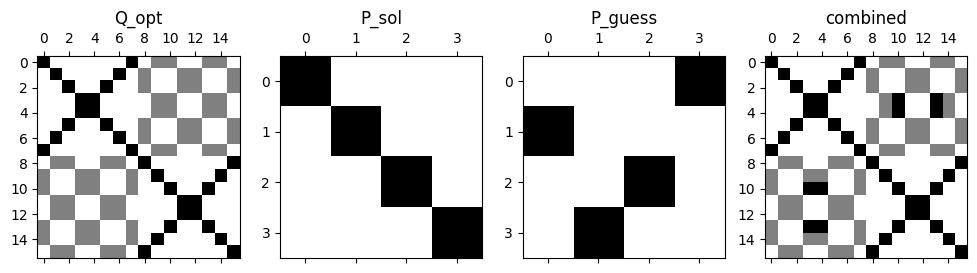

In [67]:
from functools import reduce

n = 2
N = 2**n
k = 1
k_phi = 1

def kron_power(A, k):
    """Return A^{⊗k} as a dense array. k=0 returns [[1.0]]."""
    if k == 0:
        return np.array([[1.0]], dtype=A.dtype)
    return reduce(np.kron, [A]*k)

J = np.ones((N, N)) 
#J = reduce(np.kron, [(I+X+Y+Z)/2]*n)

def Phi(M, k_phi):
    return M - k_local_projector(M, k_phi)

A = Phi(J, k_phi)

#for i, perm in enumerate(itertools.permutations(range(N))):
#    if i > 10:
#        break

for perm in distinct_random_perms(N, 1):

    perm = list(perm)
    
    P = np.eye(len(perm))[perm].T
    print("Perm:", perm)
    #print(P)
    #B = random_k_local(n, k, dist_coeff="uniform", dist_local="uniform")
    #B = hypercube_adjacency_dense(n)
    B = random_graph(N, 3/N, None)
    #B = B[perm][:, perm]
    
    print("Tr(A Phi(B)):", np.trace(A @ B))

    opt, Q_opt, P_opt = sdp_relaxation(A, B, solver="SCS")
    print("Tr((B ⊗ A) Q):", opt)
    
    #print(P_opt)
    
    #P_sol_outter = np.outer(P.T.reshape(N**2), P.T.reshape(N**2))

    #print(np.trace(A @ B))
    #print(np.trace(A @ P_opt @ B @ P_opt))
    #print(np.trace(np.kron(B, A) @ Q_opt))

    
    #eig = np.linalg.eig(Q_opt)
    '''
    for which_eig in range(len(eig.eigenvalues)):
        val = eig.eigenvalues[which_eig]
        vec = eig.eigenvectors[:, which_eig]
        print(f"eigenval {which_eig}:", val)
        print(f"eigenvec {which_eig}:", vec)
    '''
    
    #filtered_mat = 0
    #for i in range():
    #    filtered_mat += eig.eigenvalues[i]*np.outer(eig.eigenvectors[:, i], eig.eigenvectors[:, i])
    
    #Q_opt = (Q_opt >= 1E-5).astype(int)
    #guess_perm = extract_permutation_from_Q(Q_opt)[0]
    #P_guess = np.eye(len(guess_perm))[guess_perm]
    P_guess, guess_perm = get_exact_permutation_from_Q(Q_opt)
    print(guess_perm)
    
    vec_P_guess = P_guess.reshape(N**2)
    P_guess_outter = np.outer(vec_P_guess, vec_P_guess)
    
    #P_guess = #extract_P_from_Q_onefunc(Q_opt, n)[0]
    #print(P_guess)

    #S = x_like_block_mask_rowwise(Q_opt,n)
    #P_guess, _ = solve_flip_conjugacy(S, n)
    #P_guess = P.T
    
    print("Tr(A P_guess^T B P_guess):", np.trace(A @ P_guess.T @ B @ P_guess))
    
    #GPG = double_coset(inverse_perm(perm), n, "local")
    #P_outter_local = double_coset_outter_sum(GPG, n)
    
    #print(Q_opt[0:8, 56:])
    
    #plt.matshow(np.kron(B, A), cmap='binary',vmin=0, vmax=1); #plt.colorbar(label="Value"); plt.title("kron(B, A)")

    fig, axes = plt.subplots(1,4, figsize=(12, 10))

    axes[0].matshow(Q_opt/np.max(Q_opt), cmap='binary',vmin=0, vmax=1); axes[0].set_title("Q_opt")#; fig.colorbar(im)
    axes[1].matshow(P.T, cmap='binary',vmin=0, vmax=1); axes[1].set_title("P_sol")
    axes[2].matshow(P_guess, cmap='binary',vmin=0, vmax=1); axes[2].set_title("P_guess")
    axes[3].matshow(Q_opt/np.max(Q_opt) + P_guess_outter, cmap='binary',vmin=0, vmax=1); axes[3].set_title("combined")#; fig.colorbar(im)
    #axes[2].matshow(P_outter, cmap='binary',vmin=0, vmax=1); axes[2].set_title("solution_P_outter")
    #axes[3].matshow(P_outter_local, cmap='binary',vmin=0, vmax=1); axes[3].set_title("solution_P_outter_local")
    
    plt.show()
    
    #plt.matshow(np.kron(B, A) @ Q_opt, cmap='binary',vmin=0, vmax=1); plt.colorbar(label="Value"); plt.title("kron(B, A) @ Q_opt")

## Q_opt eigenvectors

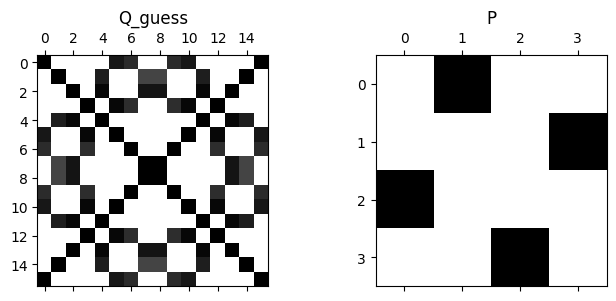

In [ ]:
n = 2
N = 2**n
k = 1

J = np.ones((N, N)) 

def Phi(M):
    return M - k_local_projector(M, k)

A = np.ones((N, N)) - k_local_projector(np.ones((N, N)), k)

Q_guess = np.zeros((N**2, N**2))

for perm in itertools.permutations(range(N)):
    
    perm = list(perm)
    
    P = np.eye(len(perm))[perm]
    #print("Perm:", perm)
    #print(P)
    B = random_k_local(n, k)
    B = B[perm][:, perm]
    
    perm_cost = np.trace(J @ Phi(B))
    
    #print("Tr(J Phi(P^T B P)):", perm_cost)
    
    if abs(perm_cost) <= 1E-10:
        P_outter = np.outer(P.reshape(N**2), P.reshape(N**2))
        Q_guess += (0.5 + 0.5*np.random.random()) * P_outter

for _ in range(1): 
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    P = extract_permutation(Q_guess)
    
    axes[0].matshow(Q_guess, cmap='binary',vmin=0, vmax=1); axes[0].set_title("Q_guess")
    axes[1].matshow(P, cmap='binary',vmin=0, vmax=1); axes[1].set_title("P")
    plt.show()

    vecP = P.reshape(N**2)
    Q_guess -= np.outer(vecP, vecP)

In [ ]:
from itertools import permutations

# ---------------- Core utils ----------------
def compose(a, b):
    """a∘b on the same domain (apply b first, then a)."""
    return tuple(a[b[i]] for i in range(len(a)))

def invert(p):
    inv = [0]*len(p)
    for i, pi in enumerate(p):
        inv[pi] = i
    return tuple(inv)

def identity(n):
    return tuple(range(1 << n))

# ----- Affine maps on the hypercube: x -> pi(x xor v) -----
def apply_affine(x, pi, v):
    """x -> pi(x xor v). 'pi' permutes bit positions; 'v' is a bit-flip mask."""
    y = x ^ v
    out = 0
    for j, newpos in enumerate(pi):
        bit = (y >> j) & 1
        out |= (bit << newpos)
    return out

def perm_array_from_affine(n, pi, v):
    D = 1 << n
    return tuple(apply_affine(x, pi, v) for x in range(D))

# ---------------- Build groups by mode ----------------
def build_group(n, mode="both"):
    """
    mode:
      - "site"  : only site permutations S_n (v = 0)
      - "local" : only local flips (Z2)^n    (pi = id)
      - "both"  : full G = (Z2)^n ⋊ S_n
    Returns a list of permutations (tuples of length 2^n).
    """
    D = 1 << n
    id_pi = tuple(range(n))
    group = []

    if mode == "site":
        for pi in permutations(range(n)):
            group.append(perm_array_from_affine(n, pi, 0))
    elif mode == "local":
        for v in range(D):
            group.append(perm_array_from_affine(n, id_pi, v))
    elif mode == "both":
        for pi in permutations(range(n)):
            for v in range(D):
                group.append(perm_array_from_affine(n, pi, v))
    else:
        raise ValueError("mode must be 'site', 'local', or 'both'.")

    return group

# ---------------- Double coset ----------------
def double_coset(P, n, mode="both", cap=None):
    """
    Return the set { A P B : A,B in G(mode) }.
    - P: permutation array (tuple) over 2^n states
    - n: number of qubits
    - mode: 'site' | 'local' | 'both' (same mode on left and right)
    - cap: optional cap on output size (early stop)
    """
    G = build_group(n, mode)
    out = set()
    for A in G:
        AP = compose(A, P)
        for B in G:
            el = compose(AP, B)
            out.add(el)
            if cap and len(out) >= cap:
                return out
    return out

# -------------- Optional: different modes on left/right --------------
def double_coset_lr(P, n, left_mode="both", right_mode="both", cap=None):
    """
    Like double_coset, but allows different groups on the left and right:
      { A P B : A in G(left_mode), B in G(right_mode) }.
    """
    GL = build_group(n, left_mode)
    GR = build_group(n, right_mode)
    out = set()
    for A in GL:
        AP = compose(A, P)
        for B in GR:
            el = compose(AP, B)
            out.add(el)
            if cap and len(out) >= cap:
                return out
    return out

# ---------------- Example ----------------
if __name__ == "__main__":
    n = 3
    D = 1 << n

    # Example permutation: swap 6 <-> 7 (the transposition (6 7))
    P = list(range(D))
    P[6], P[7] = P[7], P[6]
    P = tuple(P)

    # Double coset using only site permutations
    DC_site = double_coset(P, n, mode="site")
    print("Site-only |G|:", len(build_group(n, "site")), "|DC_site|:", len(DC_site))

    # Double coset using only local flips
    DC_local = double_coset(P, n, mode="local")
    print("Local-only |G|:", len(build_group(n, "local")), "|DC_local|:", len(DC_local))

    # Double coset using full group (both)
    DC_both = double_coset(P, n, mode="both")
    print("Both |G|:", len(build_group(n, "both")), "|DC_both|:", len(DC_both))

    # If you want different choices left vs right:
    DC_left_site_right_local = double_coset_lr(P, n, left_mode="site", right_mode="local")
    print("|DC_left_site_right_local|:", len(DC_left_site_right_local))

Site-only |G|: 6 |DC_site|: 18
Local-only |G|: 8 |DC_local|: 32
Both |G|: 48 |DC_both|: 576
|DC_left_site_right_local|: 48


32


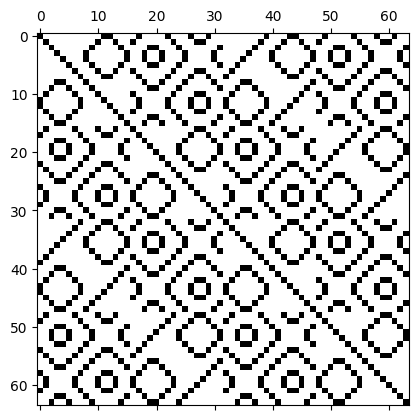

In [ ]:
n = 3
N = 1 << n
#G = build_group(n, "local")

# P = (6 7) in array form
P = [5, 3, 6, 4, 0, 2, 7, 1] #[4, 7, 5, 1, 3, 0, 2, 6]

# Compute G P G and check identity membership
GPG = double_coset(P, n, "local")

print(len(GPG))

Q_guess = 0
for perm in GPG:
    perm = list(perm)
    perm_mat = np.eye(len(perm))[perm].T
    P_outter = np.outer(perm_mat.reshape(N**2), perm_mat.reshape(N**2))
    Q_guess += P_outter
plt.matshow(Q_guess, cmap='binary',vmin=0, vmax=1)

(0, 1, 3, 2)


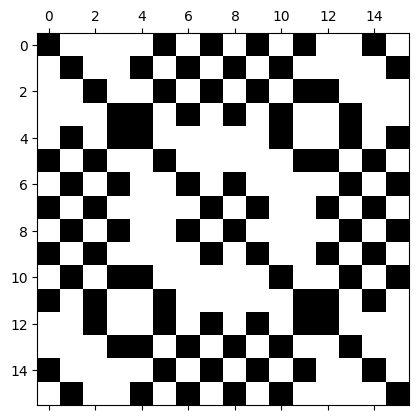

In [ ]:
from itertools import product, permutations


def apply_affine(x, pi, v):
    """x -> pi(x xor v): pi permutes bits, v is flip mask."""
    y = x ^ v
    out = 0
    for j, newpos in enumerate(pi):
        bit = (y >> j) & 1
        out |= (bit << newpos)
    return out

def perm_array_from_affine(n, pi, v):
    D = 1 << n
    return tuple(apply_affine(x, pi, v) for x in range(D))

def build_G_qubits(n):
    """All locality-preserving permutations G = (Z2)^n ⋊ S_n."""
    D = 1 << n
    G = []
    for pi in permutations(range(n)):
        for v in range(D):
            G.append(perm_array_from_affine(n, pi, v))
    return G  # |G| = 2^n n!

def compose(a, b):
    """a∘b on same domain (apply b then a)."""
    return tuple(a[b[i]] for i in range(len(a)))

# Example usage --------------------------------------------------------
if __name__ == "__main__":
    n = 2
    D = 1 << n
    # Base permutation P: swap 6<->7  (i.e. (6 7))
    P = list(range(D))
    P[-1], P[-2] = P[-2], P[-1]
    #P[6], P[7] = P[7], P[6]
    P = tuple(P)
    print(P)

    # Build G and all P_i = P B
    G = build_G_qubits(n)
    right_class = [compose(P, B) for B in G]

    Q_guess = 0
    for perm in right_class:
        perm = list(perm)
        perm_mat = np.eye(len(perm))[perm]
        P_outter = np.outer(perm_mat.reshape(D**2), perm_mat.reshape(D**2))
        Q_guess += P_outter
    plt.matshow(Q_guess, cmap='binary',vmin=0, vmax=1)

## SciPy quadratic assignment

In [ ]:
import scipy
from scipy.optimize import quadratic_assignment

n = 6
N = 2**n
k = 2

B = random_k_local(n, k, seed=103025)
rand_perm = np.random.permutation(N).tolist()
B_perm = B[rand_perm][:, rand_perm]

A = np.ones((N, N)) - k_local_projector(np.ones((N, N)), k)

print(rand_perm)
print(np.trace(A @ B_perm))

res = quadratic_assignment(A, B_perm, "2opt", options={"shuffle_input": True, 
                                                       "tol": 0, 
                                                       "maxiter": 10000,
                                                       "P0": "barycenter"})
res#, res.col_ind

[29, 56, 40, 31, 24, 50, 62, 12, 20, 6, 18, 32, 10, 13, 0, 33, 53, 54, 28, 61, 34, 52, 30, 43, 19, 16, 11, 8, 38, 60, 35, 44, 4, 49, 47, 57, 7, 42, 55, 17, 3, 9, 2, 15, 14, 27, 37, 58, 26, 25, 59, 41, 39, 36, 21, 48, 51, 63, 5, 46, 45, 1, 22, 23]
264.51087588137676


/tmp/ipykernel_1880487/420722231.py:17: OptimizeWarning: Unknown solver options: shuffle_input, tol, maxiter, P0
  res = quadratic_assignment(A, B_perm, "2opt", options={"shuffle_input": True,


     fun: 91.65761442742942
 col_ind: [27 29 ... 20 30]
     nit: 41255

In [ ]:
n = 2
N = 2**n
k = 1



B = np.kron(X, P0)

print(Phi(B))

print(Phi(B))
print(np.trace(Phi(J) @ B))

[[ 0.   0.   0.5  0. ]
 [ 0.   0.   0.  -0.5]
 [ 0.5  0.   0.   0. ]
 [ 0.  -0.5  0.   0. ]]
[[ 0.   0.   0.5  0. ]
 [ 0.   0.   0.  -0.5]
 [ 0.5  0.   0.   0. ]
 [ 0.  -0.5  0.   0. ]]
0.0


In [ ]:
k_local_projector(np.kron(Y, Y), 1)

array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])

In [ ]:
scipy.optimize.show_options("quadratic_assignment")



faq
===

Solve the quadratic assignment problem (approximately).

    This function solves the Quadratic Assignment Problem (QAP) and the
    Graph Matching Problem (GMP) using the Fast Approximate QAP Algorithm
    (FAQ) [1]_.

    Quadratic assignment solves problems of the following form:

    .. math::

        \min_P & \ {\ \text{trace}(A^T P B P^T)}\\
        \mbox{s.t. } & {P \ \epsilon \ \mathcal{P}}\\

    where :math:`\mathcal{P}` is the set of all permutation matrices,
    and :math:`A` and :math:`B` are square matrices.

    Graph matching tries to *maximize* the same objective function.
    This algorithm can be thought of as finding the alignment of the
    nodes of two graphs that minimizes the number of induced edge
    disagreements, or, in the case of weighted graphs, the sum of squared
    edge weight differences.

    Note that the quadratic assignment problem is NP-hard. The results given
    here are approximations and are not guaranteed to be optimal.

    Para

# ABS-QAP SDP relaxation

In [25]:
# pip install cvxpy numpy
import cvxpy as cp
import numpy as np

def sdp_sumPhi(phi, H, solver="SCS", order="F"):
    """
    min_{Q,P}  Tr(C Q)
    s.t.       [ Q           vec(P) ] ⪰ 0
               [ vec(P)^T        1  ]
               sum_i Q_ii = I_n
               Tr(Q_ij)   = 0           (i ≠ j)
               Tr(Q_ij J) = 1           (all i,j)
               diag(Q_ii) = P[:, i]
               P ∈ DS(n),  Q ≥ 0  (entrywise)

    Conventions match your sdp_relaxation(): Fortran vec if order="F".
    """
    H = np.asarray(H, order=order)
    n = H.shape[0]; N = n*n
    assert H.shape == (n, n)

    # --- Build L: vec(phi(M)) = L vec(M)
    sample = phi(np.zeros_like(H))
    use_complex = np.iscomplexobj(H) or np.iscomplexobj(sample)
    L = np.zeros((N, N), dtype=complex if use_complex else float)

    def fidx(i, j):  # vec index consistent with 'order'
        return (i + j*n) if order == "F" else (i*n + j)

    for p in range(n):
        for q in range(n):
            E = np.zeros((n, n), dtype=H.dtype); E[p, q] = 1.0
            FE = phi(E)
            L[:, fidx(p, q)] = np.asarray(FE).reshape(-1, order=order)

    # --- Build constant C so that Tr(C Q) = sum_{ij} Phi(P^T H P)_{ij}
    w = np.ones((n, n)).reshape(-1, order=order)  # vec(J)
    a = (L.T @ w)                                  # length N
    A = a.reshape((n, n), order=order)
    C = np.kron(H, A)

    # --- Variables
    Q = cp.Variable((N, N))
    P = cp.Variable((n, n))

    # --- Constraints (same as your template)
    vP = cp.vec(P, order=order)
    LMI = cp.bmat([[Q,                  cp.reshape(vP, (N, 1), order=order)],
                   [cp.reshape(vP, (1, N), order=order), cp.reshape(cp.Constant(1.0), (1, 1), order=order)]])
    constraints = [LMI >> 0]

    def blk(i, j):
        rows = slice(i*n, (i+1)*n)
        cols = slice(j*n, (j+1)*n)
        return Q[rows, cols]

    constraints += [sum(blk(i, i) for i in range(n)) == np.eye(n)]
    for i in range(n):
        for j in range(n):
            Qij = blk(i, j)
            constraints += [cp.sum(Qij) == 1]
            if i != j:
                constraints += [cp.trace(Qij) == 0]
    for i in range(n):
        constraints += [cp.diag(blk(i, i)) == P[:, i]]

    e = np.ones(n)
    constraints += [P >= 0, P @ e == e, P.T @ e == e, Q >= 0]

    # --- Objective: **minimize** Tr(C Q)
    prob = cp.Problem(cp.Minimize(cp.trace(C @ Q)), constraints)

    if solver == "MOSEK":
        prob.solve(solver=cp.MOSEK, verbose=False)
    elif solver == "SCS":
        prob.solve(solver=cp.SCS, verbose=False)
    else:
        prob.solve(verbose=False)

    return prob.value, Q.value, P.value

def sdp_sumPhiAbs(phi, H, solver="SCS", order="F"):
    """
    min_{Q,P}  sum_{ij} t_ij
    s.t.       [ Q           vec(P) ] ⪰ 0
               [ vec(P)^T        1  ]
               -t_ij ≤ Tr(H ⊗ mat(Phi_ij) Q) ≤ t_ij
               sum_i Q_ii = I_n
               Tr(Q_ij)   = 0           (i ≠ j)
               Tr(Q_ij J) = 1           (all i,j)
               diag(Q_ii) = P[:, i]
               P ∈ DS(n),  Q ≥ 0  (entrywise)

    Conventions match your sdp_relaxation(): Fortran vec if order="F".
    """
    H = np.asarray(H, order=order)
    n = H.shape[0]; N = n*n
    assert H.shape == (n, n)

    # --- Build L: vec(phi(M)) = L vec(M)
    sample = phi(np.zeros_like(H))
    use_complex = np.iscomplexobj(H) or np.iscomplexobj(sample)
    L = np.zeros((N, N), dtype=complex if use_complex else float)

    def fidx(i, j):  # vec index consistent with 'order'
        return (i + j*n) if order == "F" else (i*n + j)

    for p in range(n):
        for q in range(n):
            E = np.zeros((n, n), dtype=H.dtype); E[p, q] = 1.0
            FE = phi(E)
            L[:, fidx(p, q)] = np.asarray(FE).reshape(-1, order=order)

    # --- Variables
    Q = cp.Variable((N, N))
    P = cp.Variable((n, n))
    t = cp.Variable((n, n), nonneg=True)

    # --- Constraints (same as your template)
    vP = cp.vec(P, order=order)
    LMI = cp.bmat([[Q,                  cp.reshape(vP, (N, 1), order=order)],
                   [cp.reshape(vP, (1, N), order=order), cp.reshape(cp.Constant(1.0), (1, 1), order=order)]])
    constraints = [LMI >> 0]

    def blk(i, j):
        rows = slice(i*n, (i+1)*n)
        cols = slice(j*n, (j+1)*n)
        return Q[rows, cols]

    constraints += [sum(blk(i, i) for i in range(n)) == np.eye(n)]
    for i in range(n):
        for j in range(n):
            Qij = blk(i, j)
            constraints += [cp.sum(Qij) == 1]
            if i != j:
                constraints += [cp.trace(Qij) == 0]
    for i in range(n):
        constraints += [cp.diag(blk(i, i)) == P[:, i]]

    e = np.ones(n)
    constraints += [P >= 0, P @ e == e, P.T @ e == e, Q >= 0]
    
    # add abs constraints
    for i in range(n):
        vi = np.zeros((n, 1))
        vi[i, 0] = 1.0
        for j in range(n):
            vj = np.zeros((n, 1))
            vj[j, 0] = 1.0
            
            vij = np.kron(vi, vj)
            
            a = (L.T @ vij)                                  # length N
            A = a.reshape((n, n), order=order)
            Cij = np.kron(H, A)

            constraints += [-t[i][j] <= cp.trace(Cij @ Q), cp.trace(Cij @ Q) <= t[i][j]]

    # --- Objective: **minimize** sum of t
    prob = cp.Problem(cp.Minimize(cp.sum(t)), constraints)

    if solver == "MOSEK":
        prob.solve(solver=cp.MOSEK, verbose=False)
    elif solver == "SCS":
        prob.solve(solver=cp.SCS, verbose=False)
    else:
        prob.solve(verbose=False)

    return prob.value, Q.value, P.value, t.value

def sdp_PauliAbs(H, nq, k, solver="MOSEK", order="F", obj="weighted"):
    """
    min_{t,Q,P}  sum_{k} t_i
    s.t.       [ Q           vec(P) ] ⪰ 0
               [ vec(P)^T        1  ]
               -t_i ≤ Tr(Pauli_i Q) ≤ t_i
               sum_i Q_ii = I_n
               Tr(Q_ij)   = 0           (i ≠ j)
               Tr(Q_ij J) = 1           (all i,j)
               diag(Q_ii) = P[:, i]
               P ∈ DS(n),  Q ≥ 0  (entrywise)

    Conventions match your sdp_relaxation(): Fortran vec if order="F".
    """
    H = np.asarray(H, order=order)
    n = H.shape[0]; N = n*n
    assert H.shape == (n, n)
    
    # --- Variables
    Q = cp.Variable((N, N))
    P = cp.Variable((n, n))
    t = cp.Variable((sum(math.comb(nq, w) * 3**w for w in range(k+1, nq+1))), nonneg=True)

    # --- Constraints (same as your template)
    vP = cp.vec(P, order=order)
    LMI = cp.bmat([[Q,                  cp.reshape(vP, (N, 1), order=order)],
                   [cp.reshape(vP, (1, N), order=order), cp.reshape(cp.Constant(1.0), (1, 1), order=order)]])
    constraints = [LMI >> 0]

    def blk(i, j):
        rows = slice(i*n, (i+1)*n)
        cols = slice(j*n, (j+1)*n)
        return Q[rows, cols]

    constraints += [sum(blk(i, i) for i in range(n)) == np.eye(n)]
    for i in range(n):
        for j in range(n):
            Qij = blk(i, j)
            constraints += [cp.sum(Qij) == 1]
            if i != j:
                constraints += [cp.trace(Qij) == 0]
    for i in range(n):
        constraints += [cp.diag(blk(i, i)) == P[:, i]]

    e = np.ones(n)
    constraints += [P >= 0, P @ e == e, P.T @ e == e, Q >= 0]
    
    # --- Add abs constraints
    weights = []
    for (i, (Pauli_label, Pauli_i)) in enumerate(generate_pauli_matrices(nq, k)):
        w = nq - Pauli_label.count("I")
        if w == 2:
            weights.append(1)
        else:
            weights.append(2*(w-1))
        Ci = np.real(np.kron(H, Pauli_i))
        constraints += [-t[i] <= cp.trace(Ci @ Q), cp.trace(Ci @ Q) <= t[i]]
    weights = np.array(weights)

    # --- Objective: **minimize** sum of t
    if obj == "weighted":
        prob = cp.Problem(cp.Minimize(cp.sum(cp.multiply(weights, t))), constraints)
    else:
        prob = cp.Problem(cp.Minimize(cp.sum(t)), constraints)

    if solver == "MOSEK":
        prob.solve(solver=cp.MOSEK, verbose=False, canon_backend="SCIPY")
    elif solver == "SCS":
        prob.solve(solver=cp.SCS, verbose=False)
    else:
        prob.solve(verbose=False)

    return prob.value, Q.value, P.value, t.value

'''
import numpy as np, math, scipy.sparse as sp, cvxpy as cp

def sdp_PauliAbs_memory(H, nq, k, solver="MOSEK", order="F"):
    """
    Memory-safe SDP for min sum |Tr(C_i Q)| with
    C_i = kron(H, Pauli_i) and |.| enforced via t.
    Uses one sparse linear map A so that z = A @ vec(Q).
    """
    H = np.asarray(H, dtype=float, order=order)
    n = H.shape[0]
    N = n * n
    assert H.shape == (n, n)

    # --- Variables
    Q = cp.Variable((N, N))
    P = cp.Variable((n, n))
    e = np.ones(n)

    vP = cp.vec(P, order=order)
    LMI = cp.bmat([[Q,                  cp.reshape(vP, (N, 1), order=order)],
                   [cp.reshape(vP, (1, N), order=order), [[1.0]]]])
    constraints = [LMI >> 0]

    # Block helpers
    def blk(i, j):
        return Q[i*n:(i+1)*n, j*n:(j+1)*n]

    # Constraints (your template)
    constraints += [sum(blk(i, i) for i in range(n)) == np.eye(n)]
    for i in range(n):
        for j in range(n):
            Qij = blk(i, j)
            constraints += [cp.sum(Qij) == 1]
            if i != j:
                constraints += [cp.trace(Qij) == 0]
    for i in range(n):
        constraints += [cp.diag(blk(i, i)) == P[:, i]]
    constraints += [P >= 0, P @ e == e, P.T @ e == e, Q >= 0]

    # ===== Build A so that z = A @ vec(Q), z_i = Tr(C_i Q) =====
    paulis = list(generate_pauli_matrices(nq, k))  # your generator: (label, Pi)
    M = len(paulis)
    t = cp.Variable(M, nonneg=True)

    # A has shape (M, N*N). Row i = vec(C_i^T)^T with C_i = kron(H, Pi)
    data, rows, cols = [], [], []
    for i, (_, Pi) in enumerate(paulis):
        Ci = np.real(np.kron(H, Pi))         # N x N dense small; we'll add as sparse row
        # we need vec(Ci^T), so iterate nonzeros of Ci and map (r,c) -> index of (c,r)
        Ci_coo = sp.coo_matrix(Ci)           # sparse view for index arithmetic
        rr, cc, vv = Ci_coo.row, Ci_coo.col, Ci_coo.data

        if order == "F":
            # Fortran vec: idx(r,c) = r + c*N; so vec(Ci^T) uses (c,r) -> c + r*N
            col_idx = cc + rr * N
        else:  # order == "C"
            # C vec: idx(r,c) = r*N + c; so vec(Ci^T) uses (c,r) -> c*N + r
            col_idx = cc * N + rr

        rows.extend([i] * len(vv))
        cols.extend(col_idx.tolist())
        data.extend(vv.tolist())

    A = sp.csr_matrix((data, (rows, cols)), shape=(M, N * N))

    # Vectorize Q with the same order and form z
    qvec = cp.vec(Q, order=order)            # shape (N*N,)
    z = A @ qvec                             # affine CVXPY expression, shape (M,)

    # |z| <= t  (elementwise)
    constraints += [-t <= z, z <= t]

    # --- Objective
    prob = cp.Problem(cp.Minimize(cp.sum(t)), constraints)

    # --- Solve (sparse canon backend!)
    solve_kwargs = dict(verbose=True, canon_backend="SCIPY")
    if solver == "MOSEK":
        prob.solve(solver=cp.MOSEK, **solve_kwargs)
    elif solver == "SCS":
        prob.solve(solver=cp.SCS, use_indirect=True, eps=1e-4, max_iters=30000, **solve_kwargs)
    else:
        prob.solve(**solve_kwargs)

    return prob.value, Q.value, P.value, t.value
'''

'\nimport numpy as np, math, scipy.sparse as sp, cvxpy as cp\n\ndef sdp_PauliAbs_memory(H, nq, k, solver="MOSEK", order="F"):\n    """\n    Memory-safe SDP for min sum |Tr(C_i Q)| with\n    C_i = kron(H, Pauli_i) and |.| enforced via t.\n    Uses one sparse linear map A so that z = A @ vec(Q).\n    """\n    H = np.asarray(H, dtype=float, order=order)\n    n = H.shape[0]\n    N = n * n\n    assert H.shape == (n, n)\n\n    # --- Variables\n    Q = cp.Variable((N, N))\n    P = cp.Variable((n, n))\n    e = np.ones(n)\n\n    vP = cp.vec(P, order=order)\n    LMI = cp.bmat([[Q,                  cp.reshape(vP, (N, 1), order=order)],\n                   [cp.reshape(vP, (1, N), order=order), [[1.0]]]])\n    constraints = [LMI >> 0]\n\n    # Block helpers\n    def blk(i, j):\n        return Q[i*n:(i+1)*n, j*n:(j+1)*n]\n\n    # Constraints (your template)\n    constraints += [sum(blk(i, i) for i in range(n)) == np.eye(n)]\n    for i in range(n):\n        for j in range(n):\n            Qij = blk(i

## Plot Q_opt

[[0 0 1 0 0 0 1 0]
 [0 0 0 1 0 1 0 0]
 [1 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 1]
 [0 1 0 0 0 0 0 1]
 [1 0 0 1 0 0 0 0]
 [0 0 0 0 1 1 0 0]]
Pauli_coeff_weighted_abs_sum(H): 84.0


t_opt: [1.61673318e-10 0.00000000e+00 2.48452738e-13 0.00000000e+00
 2.48452226e-13 0.00000000e+00 2.48451479e-13 0.00000000e+00
 0.00000000e+00 1.61673301e-10 0.00000000e+00 2.48446279e-13
 0.00000000e+00 2.48452226e-13 0.00000000e+00 2.48453071e-13
 0.00000000e+00 0.00000000e+00 1.61673307e-10 0.00000000e+00
 2.48453341e-13 0.00000000e+00 2.48452226e-13 0.00000000e+00
 2.48459373e-13 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
sum t: 4.872559983820435e-10
Pauli_coeff_weighted_abs_sum(P_guess^T H P_guess): 8.0


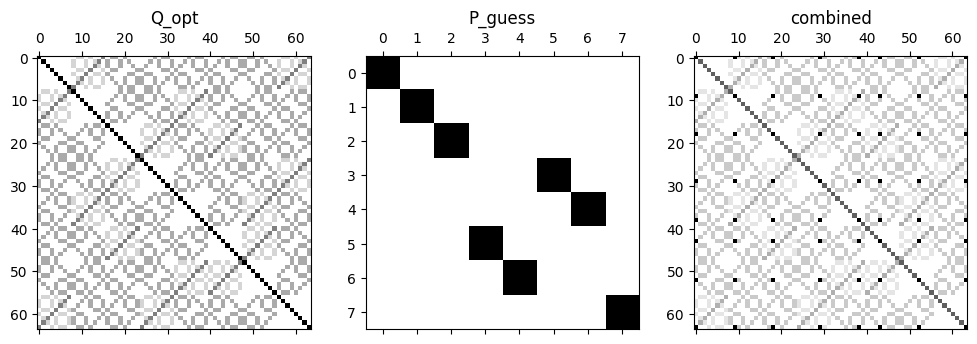

In [84]:
from functools import reduce

n = 3
N = 2**n
k = 1
k_phi = 1

def Phi(M):
    return M - k_local_projector(M, k_phi)

#for i, perm in enumerate(itertools.permutations(range(N))):
#    if i > 10:
#        break

#for perm in distinct_random_perms(N, 1):

#for perm in [[0, 1, 3, 2, 7, 6, 4, 5], [0, 7, 3, 4, 2, 5, 1, 6], [6, 7, 1, 0, 5, 4, 2, 3]]:

for perm in [list(range(2**n))]:

    perm = list(perm)
    
    #H = band_matrix_n_qubits(n, 1, periodic=True)
    #H = hypercube_adjacency_dense(n)
    #H = random_k_local(n, k, dist_coeff="positive", dist_local="positive")
    #H = random_graph(N, 3/N, None)
    H = [[0, 0, 1, 0, 0, 0, 1, 0],
         [0, 0, 0, 1, 0, 1, 0, 0],
         [1, 0, 0, 0, 1, 0, 0, 0],
         [0, 1, 0, 0, 0, 0, 1, 0],
         [0, 0, 1, 0, 0, 0, 0, 1],
         [0, 1, 0, 0, 0, 0, 0, 1],
         [1, 0, 0, 1, 0, 0, 0, 0],
         [0, 0, 0, 0, 1, 1, 0, 0]]
    H = np.array(H)
            
    P = np.eye(len(perm))[perm].T
    #print("Perm:", perm)
    #print(P)
    #H = random_k_local(n, k, dist_coeff="uniform", dist_local="uniform")
    #H = P.T @ H @ P
    
    print(H)
    
    print("Pauli_coeff_weighted_abs_sum(H):", Pauli_coeff_abs_sum(H, n, k_phi))

    opt, Q_opt, P_opt, t_opt = sdp_PauliAbs(H, n, k_phi, solver="MOSEK", obj="weighted")
    print("t_opt:", t_opt)
    print("sum t:", opt)
    
    #print(P_opt)
    
    #P_sol_outter = np.outer(P.T.reshape(N**2), P.T.reshape(N**2))
    
    #eig = np.linalg.eig(Q_opt)
    '''
    for which_eig in range(len(eig.eigenvalues)):
        val = eig.eigenvalues[which_eig]
        vec = eig.eigenvectors[:, which_eig]
        print(f"eigenval {which_eig}:", val)
        print(f"eigenvec {which_eig}:", vec)
    '''
    
    #filtered_mat = 0
    #for i in range():
    #    filtered_mat += eig.eigenvalues[i]*np.outer(eig.eigenvectors[:, i], eig.eigenvectors[:, i])
    
    #Q_opt = (Q_opt >= 1E-5).astype(int)
    #guess_perm = extract_permutation_from_Q(Q_opt)[0]
    #P_guess = np.eye(len(guess_perm))[guess_perm]
    
    #P_guess = #extract_P_from_Q_onefunc(Q_opt, n)[0]
    #print(P_guess)
    
    P_guess, guess_perm = get_exact_permutation(H, n, k) #get_exact_permutation_from_Q(Q_opt)
    
    vec_P_guess = P_guess.reshape(N**2)
    P_guess_outter = np.outer(vec_P_guess, vec_P_guess)

    #S = x_like_block_mask_rowwise(Q_opt,n)
    #P_guess, _ = solve_flip_conjugacy(S, n)
    #P_guess = P.T
    
    print("Pauli_coeff_weighted_abs_sum(P_guess^T H P_guess):", Pauli_coeff_abs_sum(P_guess.T @ H @ P_guess, n, k_phi))
    
    #print("Pauli_coeff_abs_sum(P_opt^T H P_opt):", Pauli_coeff_abs_sum(P_opt.T @ H @ P_opt, n, k_phi))
    
    #GPG = double_coset(inverse_perm(perm), n, "local")
    #P_outter_local = double_coset_outter_sum(GPG, n)
    
    #print(Q_opt[0:8, 56:])
    
    #plt.matshow(np.kron(B, A), cmap='binary',vmin=0, vmax=1); #plt.colorbar(label="Value"); plt.title("kron(B, A)")

    fig, axes = plt.subplots(1,3, figsize=(12, 10))

    axes[0].matshow(Q_opt/np.max(Q_opt), cmap='binary',vmin=0, vmax=1); axes[0].set_title("Q_opt")#; fig.colorbar(im)
    #axes[1].matshow(P.T, cmap='binary',vmin=0, vmax=1); axes[1].set_title("P_sol")
    axes[1].matshow(P_guess, cmap='binary',vmin=0, vmax=1); axes[1].set_title("P_guess")
    axes[2].matshow(Q_opt*5 + P_guess_outter, cmap='binary',vmin=0, vmax=1); axes[2].set_title("combined")#; fig.colorbar(im)
    #axes[2].matshow(P_opt, cmap='binary',vmin=0, vmax=1); axes[2].set_title("P_opt")
    #axes[2].matshow(P_outter, cmap='binary',vmin=0, vmax=1); axes[2].set_title("solution_P_outter")
    #axes[3].matshow(P_outter_local, cmap='binary',vmin=0, vmax=1); axes[3].set_title("solution_P_outter_local")
    
    plt.show()
    
    #plt.matshow(np.kron(B, A) @ Q_opt, cmap='binary',vmin=0, vmax=1); plt.colorbar(label="Value"); plt.title("kron(B, A) @ Q_opt")

## 8-node 3-regular test

In [12]:
opt_vals = []

for _, val in n83_dict.items():
    H = val['A']
    print(H)
    
    init_val = Pauli_coeff_abs_sum(H, 3, 1)
    print(init_val)
    
    opt, Q_opt, P_opt, t_opt = sdp_PauliAbs(H, 3, 1, solver="MOSEK", obj="weighted")
    P_guess = find_P_from_Q(Q_opt)[0]
    #print(guess_perm)
    #P_guess = np.eye(len(guess_perm))[guess_perm]
    
    opt_val = Pauli_coeff_abs_sum(P_guess.T @ H @ P_guess, 3, 1)
    print(opt_val)
    
    opt_vals.append((P_guess, opt_val))

[[0 1 1 1 0 0 0 0]
 [1 0 1 1 0 0 0 0]
 [1 1 0 1 0 0 0 0]
 [1 1 1 0 0 0 0 0]
 [0 0 0 0 0 1 1 1]
 [0 0 0 0 1 0 1 1]
 [0 0 0 0 1 1 0 1]
 [0 0 0 0 1 1 1 0]]
8.0
8.0
[[0 1 1 1 0 0 0 0]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 0 0 1 0]
 [1 1 1 0 0 0 0 0]
 [0 0 0 0 0 1 1 1]
 [0 1 0 0 1 0 0 1]
 [0 0 1 0 1 0 0 1]
 [0 0 0 0 1 1 1 0]]
24.0


KeyboardInterrupt: 

# Simulated annealing

In [26]:
import numpy as np
from tqdm.auto import tqdm  # <- progress bar

def simulated_annealing_permutation(
    H,
    obj_func,
    max_iters=50_000,
    T_start=None,
    T_end=None,
    seed=None,
    return_history=False,
    use_tqdm=True,
    tqdm_desc="SA over permutations",
):
    """
    Minimize obj(P^T H P) over permutation matrices P using simulated annealing.

    Parameters
    ----------
    H : np.ndarray, shape (N, N)
        Hermitian matrix, N must be 2**n.
    obj_func : callable
        Objective function with signature obj_func(H_perm) -> float
    max_iters : int
        Total number of SA steps.
    T_start : float or None
        Initial temperature. If None, set based on initial objective value.
    T_end : float or None
        Final temperature. If None, set to 1e-3 * T_start.
    seed : int or None
        RNG seed.
    return_history : bool
        If True, also return list of best values over time.
    use_tqdm : bool
        If True, wrap iterations in a tqdm progress bar.
    tqdm_desc : str
        Description label for tqdm.

    Returns
    -------
    P_best : np.ndarray, shape (N, N)
        Best permutation matrix found.
    perm_best : np.ndarray, shape (N,)
        Best permutation as a 1D array; H' = P^T H P is H[np.ix_(perm, perm)].
    best_cost : float
        Objective value obj_func(P_best^T H P_best, n, k).
    (optional) history : list[float]
        If return_history, a list of best_cost after each iteration.
    """
    H = np.asarray(H)
    N = H.shape[0]
    n = int(math.log2(N))
    assert H.shape == (N, N)
    assert N == 2**n, "H must be 2^n by 2^n."

    rng = np.random.default_rng(seed)

    # Initial permutation: identity
    perm = np.arange(N)
    H_perm = H  # P = I initially
    curr_cost = float(obj_func(H_perm))

    # Temperature schedule
    if T_start is None:
        T_start = 0.1 * abs(curr_cost) if curr_cost != 0 else 1.0
    if T_end is None:
        T_end = 1e-3 * T_start

    perm_best = perm.copy()
    best_cost = curr_cost

    history = [best_cost] if return_history else None

    log_T_ratio = np.log(T_end / T_start)

    # Choose iterator with or without tqdm
    iterator = range(1, max_iters + 1)
    if use_tqdm:
        iterator = tqdm(iterator, desc=tqdm_desc, leave=True)

    for it in iterator:
        # Temperature at this iteration
        T = T_start * np.exp(log_T_ratio * it / max_iters)

        # Propose neighbor: random swap of two positions
        i, j = rng.integers(0, N, size=2)
        while j == i:
            j = rng.integers(0, N)

        perm_new = perm.copy()
        perm_new[i], perm_new[j] = perm_new[j], perm_new[i]

        # Apply permutation: H' = P^T H P
        H_new = H[np.ix_(perm_new, perm_new)]

        new_cost = float(obj_func(H_new))
        delta = new_cost - curr_cost  # minimize

        # Metropolis acceptance
        if delta <= 0 or rng.random() < np.exp(-delta / T):
            perm = perm_new
            curr_cost = new_cost

            if curr_cost < best_cost:
                best_cost = curr_cost
                perm_best = perm.copy()

        if return_history:
            history.append(best_cost)

        # Optional: update postfix in tqdm
        if use_tqdm and hasattr(iterator, "set_postfix"):
            iterator.set_postfix({"best": best_cost})

    # Build permutation matrix P from perm_best
    P_best = np.zeros_like(H, dtype=float)
    P_best[np.arange(N), perm_best] = 1.0

    if return_history:
        return P_best, perm_best, best_cost, history
    else:
        return P_best, perm_best, best_cost
    
import numpy as np
import itertools
from tqdm.auto import tqdm

# ============================================================
# Neutral symmetry move: P -> canonical_perm(P ∘ a), iso-cost
# ============================================================

def _neutral_symmetry_step(perm, sym_data, rng):
    """
    Perform an iso-cost neutral step by composing perm with a random local symmetry:
        a(x) = σ(x) XOR v,
    and then canonicalizing:
        perm' = canonical_perm(perm ∘ a)
    Cost is unchanged for Pauli-weight-based objectives.
    """
    n = sym_data["n"]
    perms = sym_data["perms"]
    maps_sigma = sym_data["maps_sigma"]
    xor_map = sym_data["xor_map"]

    N = 1 << n

    # Random σ and v
    sigma_idx = rng.integers(0, len(perms))
    v = rng.integers(0, 1 << n)

    sigma_map = maps_sigma[sigma_idx]
    a_map = xor_map[v][sigma_map]  # a(x)

    perm = np.asarray(perm, dtype=np.int64)
    perm_a = perm[a_map]          # P ∘ a

    # Canonicalize within the equivalence class
    perm_can = canonical_perm(perm_a, sym_data=sym_data)
    return perm_can

# ============================================================
# Simulated annealing with optional symmetry & neutral steps
# ============================================================

def simulated_annealing_canon_perm(
    H,
    obj_func,
    max_iters=50_000,
    T_start=None,
    T_end=None,
    seed=None,
    return_history=False,
    use_tqdm=True,
    tqdm_desc="SA over permutations",
    # --- symmetry options ---
    use_symmetry=True,
    canonicalize_init=True,
    canonicalize_on_accept=True,
    canonicalize_every=10,      # only used if canonicalize_on_accept=True
    # --- neutral symmetry moves ---
    use_neutral_moves=True,
    neutral_move_prob=0.05,
):
    """
    Minimize obj(P^T H P) over permutation matrices P using simulated annealing.

    Parameters
    ----------
    H : np.ndarray, shape (N, N)
        Hermitian matrix, N must be 2**n.
    obj_func : callable
        Objective function with signature obj_func(H_perm, n, k) -> float
    max_iters : int
        Total number of SA steps.
    T_start : float or None
        Initial temperature. If None, set based on initial objective value.
    T_end : float or None
        Final temperature. If None, set to 1e-3 * T_start.
    seed : int or None
        RNG seed.
    return_history : bool
        If True, also return list of best values over time.
    use_tqdm : bool
        If True, wrap iterations in a tqdm progress bar.
    tqdm_desc : str
        Description label for tqdm.

    Symmetry options
    ----------------
    use_symmetry : bool
        If True, enable right-action symmetry canonicalization (canonical_perm).
        This preserves obj(P^T H P) for Pauli-weight-based objectives.
    canonicalize_init : bool
        If True and use_symmetry, canonicalize the initial permutation.
    canonicalize_on_accept : bool
        If True and use_symmetry, periodically canonicalize after accepted moves.
    canonicalize_every : int
        If canonicalize_on_accept is True, canonicalize after every
        'canonicalize_every' accepted moves.

    Neutral moves
    -------------
    use_neutral_moves : bool
        If True and use_symmetry, occasionally perform iso-cost "neutral" moves
        via random local symmetries plus canonicalization.
    neutral_move_prob : float
        Probability per iteration of performing a neutral move (if enabled).

    Returns
    -------
    P_best : np.ndarray, shape (N, N)
        Best permutation matrix found.
    perm_best : np.ndarray, shape (N,)
        Best permutation as a 1D array; H' = P^T H P is H[np.ix_(perm, perm)].
    best_cost : float
        Objective value obj_func(P_best^T H P_best, n, k).
    (optional) history : list[float]
        If return_history, a list of best_cost after each iteration.
    """
    H = np.asarray(H)
    N = H.shape[0]
    n = int(math.log2(N))
    assert H.shape == (N, N)
    assert N == 2**n, "H must be 2^n by 2^n."

    rng = np.random.default_rng(seed)

    # Precompute symmetry data once if needed
    sym_data = None
    if use_symmetry or use_neutral_moves:
        sym_data = _build_local_symmetry_data(n)

    # Initial permutation: identity
    perm = np.arange(N, dtype=np.int64)

    # Optional initial canonicalization
    if use_symmetry and canonicalize_init:
        perm = canonical_perm(perm, sym_data=sym_data)

    H_perm = H[np.ix_(perm, perm)]
    curr_cost = float(obj_func(H_perm))

    # Temperature schedule
    if T_start is None:
        T_start = 0.1 * abs(curr_cost) if curr_cost != 0 else 1.0
    if T_end is None:
        T_end = 1e-3 * T_start

    perm_best = perm.copy()
    best_cost = curr_cost

    history = [best_cost] if return_history else None

    log_T_ratio = np.log(T_end / T_start)
    accepted_moves = 0

    # Choose iterator with or without tqdm
    iterator = range(1, max_iters + 1)
    if use_tqdm:
        iterator = tqdm(iterator, desc=tqdm_desc, leave=True)

    for it in iterator:
        # Optional neutral symmetry move (iso-cost gauge change)
        if use_symmetry and use_neutral_moves and rng.random() < neutral_move_prob:
            perm = _neutral_symmetry_step(perm, sym_data, rng)
            # cost unchanged
            if return_history:
                history.append(best_cost)
            if use_tqdm and hasattr(iterator, "set_postfix"):
                iterator.set_postfix({"best": best_cost})
            continue

        # Temperature at this iteration
        T = T_start * np.exp(log_T_ratio * it / max_iters)

        # Propose neighbor: random swap of two positions (domain indices)
        i, j = rng.integers(0, N, size=2)
        while j == i:
            j = rng.integers(0, N)

        perm_new = perm.copy()
        perm_new[i], perm_new[j] = perm_new[j], perm_new[i]

        # Apply permutation: H' = P^T H P
        H_new = H[np.ix_(perm_new, perm_new)]
        new_cost = float(obj_func(H_new))
        delta = new_cost - curr_cost  # minimize

        # Metropolis acceptance
        if delta <= 0 or rng.random() < np.exp(-delta / T):
            perm = perm_new
            curr_cost = new_cost
            accepted_moves += 1

            # Optional canonicalization after accepted moves
            if use_symmetry and canonicalize_on_accept:
                if accepted_moves % max(1, canonicalize_every) == 0:
                    perm = canonical_perm(perm, sym_data=sym_data)
                    # cost is invariant under canonical_perm, so no recompute

            if curr_cost < best_cost:
                best_cost = curr_cost
                perm_best = perm.copy()

        if return_history:
            history.append(best_cost)

        if use_tqdm and hasattr(iterator, "set_postfix"):
            iterator.set_postfix({"best": best_cost})

    # Build permutation matrix P from perm_best
    P_best = np.zeros_like(H, dtype=float)
    P_best[np.arange(N), perm_best] = 1.0

    if return_history:
        return P_best, perm_best, best_cost, history
    else:
        return P_best, perm_best, best_cost

# Greedy algorithm

In [27]:
import numpy as np
from typing import Callable, Tuple, Optional, List
from tqdm.auto import tqdm

# --------- In-place helpers ---------
def swap_rows_inplace(A: np.ndarray, i: int, j: int) -> None:
    if i != j:
        A[[i, j], :] = A[[j, i], :]

def swap_cols_inplace(A: np.ndarray, i: int, j: int) -> None:
    if i != j:
        A[:, [i, j]] = A[:, [j, i]]

def swap_rowcol_inplace(A: np.ndarray, i: int, j: int) -> None:
    if i != j:
        swap_rows_inplace(A, i, j)
        swap_cols_inplace(A, i, j)

# --------- Greedy (focused, in-place) + tqdm ---------
def fast_greedy_minimize_perm(
    H: np.ndarray,
    obj: Callable[[np.ndarray], float],   # e.g. lambda X: Pauli_coeff_abs_sum(X, n, k)
    *,
    restarts: int = 8,
    max_outer_iters: int = 200,           # max accepted improvements per restart
    batch_pairs: int = 6_000,             # candidate pairs tested per outer loop
    focus_top: float = 0.2,               # fraction of indices used by focus
    rand_pairs_frac: float = 0.25,        # fraction of purely random pairs
    tol_improve: float = 0.0,
    seed: Optional[int] = None,
    return_history: bool = False,
    use_tqdm: bool = True,
    show_inner_swaps: bool = False,       # inner tqdm for candidate loop (can be noisy)
) -> Tuple[float, np.ndarray, np.ndarray, Optional[List[float]]]:
    """
    Faster greedy over permutations minimizing obj(P^T H P).
    Shows tqdm progress bars if use_tqdm=True.
    """
    rng = np.random.default_rng(seed)
    N = H.shape[0]
    assert H.shape == (N, N)

    def perm_to_HP(H, perm):
        return H[np.ix_(perm, perm)].copy()

    def focused_pair_candidates(HP, n_pairs, focus_frac, rand_frac):
        N = HP.shape[0]
        row_l1 = np.sum(np.abs(HP), axis=1) - np.abs(np.diag(HP))
        col_l1 = np.sum(np.abs(HP), axis=0) - np.abs(np.diag(HP))
        score = row_l1 + col_l1
        m_focus = max(2, int(focus_frac * N))
        top_idx = np.argpartition(-score, m_focus - 1)[:m_focus]

        pairs = []
        need_focus = max(0, int((1.0 - rand_frac) * n_pairs))
        while len(pairs) < need_focus:
            i = int(top_idx[rng.integers(0, len(top_idx))])
            j = rng.integers(0, N - 1)
            if j >= i: j += 1
            if i > j: i, j = j, i
            pairs.append((i, j))
        while len(pairs) < n_pairs:
            i = rng.integers(0, N)
            j = rng.integers(0, N - 1)
            if j >= i: j += 1
            if i > j: i, j = j, i
            pairs.append((i, j))
        return pairs

    global_best_val = np.inf
    global_best_perm = np.arange(N)
    global_best_HP = H.copy()
    history = []

    restarts_iter = range(restarts)
    if use_tqdm:
        restarts_iter = tqdm(restarts_iter, desc="Restarts", leave=True)

    for _ in restarts_iter:
        # random start
        perm = np.arange(N)
        rng.shuffle(perm)
        HP = perm_to_HP(H, perm)
        cur_val = obj(HP)

        accepted = 0
        improved = True

        outer_iter = range(max_outer_iters)  # we’ll break early when stuck
        if use_tqdm:
            outer_iter = tqdm(outer_iter, desc="Improvements in restart", leave=False)

        for _ in outer_iter:
            # Build candidates and scan until first improvement
            cand_pairs = focused_pair_candidates(
                HP, n_pairs=batch_pairs,
                focus_frac=focus_top,
                rand_frac=rand_pairs_frac
            )

            inner_iter = enumerate(cand_pairs)
            if use_tqdm and show_inner_swaps:
                inner_iter = tqdm(inner_iter, total=len(cand_pairs),
                                  desc="Candidate swaps", leave=False)

            found = False
            for idx, (i, j) in inner_iter:
                swap_rowcol_inplace(HP, i, j)
                new_val = obj(HP)
                if new_val + tol_improve < cur_val:
                    # accept swap permanently
                    cur_val = new_val
                    perm[i], perm[j] = perm[j], perm[i]
                    accepted += 1
                    found = True
                    break
                else:
                    # revert
                    swap_rowcol_inplace(HP, i, j)

            if not found:
                # local minimum
                break

        if cur_val < global_best_val:
            global_best_val = cur_val
            global_best_perm = perm.copy()
            global_best_HP = HP.copy()

        if return_history:
            history.append(global_best_val)
    if return_history is not None:
        return global_best_val, global_best_perm, global_best_HP
    else:
        return global_best_val, global_best_perm, global_best_HP, history

# --- Example usage ------------------------------------------------------------

'''
# Given:
#   H: (2**n, 2**n) numpy array
#   Pauli_coeff_abs_sum(X, n, k) -> float

n, k = 2, 1
N = 2**n

H = random_graph(N, 3/N, None)

obj = lambda X: Pauli_coeff_abs_sum(X, n, k)

best_val, best_perm, best_HP, hist = fast_greedy_minimize_perm(
    H, obj,
    restarts=12,
    max_outer_iters=400,     # more accepted steps if you want deeper search
    batch_pairs=8000,        # try 8k candidate swaps per iteration
    focus_top=0.2,           # focus on top 20% rows/cols by L1 activity
    rand_pairs_frac=0.2,     # 20% exploratory random pairs
    tol_improve=1e-12,
    seed=42,
    return_history=True
)

#print("Best objective:", best_val)
#print("Best permutation:", best_perm)
'''


'\n# Given:\n#   H: (2**n, 2**n) numpy array\n#   Pauli_coeff_abs_sum(X, n, k) -> float\n\nn, k = 2, 1\nN = 2**n\n\nH = random_graph(N, 3/N, None)\n\nobj = lambda X: Pauli_coeff_abs_sum(X, n, k)\n\nbest_val, best_perm, best_HP, hist = fast_greedy_minimize_perm(\n    H, obj,\n    restarts=12,\n    max_outer_iters=400,     # more accepted steps if you want deeper search\n    batch_pairs=8000,        # try 8k candidate swaps per iteration\n    focus_top=0.2,           # focus on top 20% rows/cols by L1 activity\n    rand_pairs_frac=0.2,     # 20% exploratory random pairs\n    tol_improve=1e-12,\n    seed=42,\n    return_history=True\n)\n\n#print("Best objective:", best_val)\n#print("Best permutation:", best_perm)\n'

## 8-node 3-regular test

In [14]:
'''
opt_vals = []

for _, val in n83_dict.items():
    H = val['A']
    print(H)
    
    obj = lambda X: Pauli_coeff_abs_sum(X, 3, 1)

    best_val, best_perm, best_HP, hist = fast_greedy_minimize_perm(
        H, obj,
        restarts=12,
        max_outer_iters=400,     # more accepted steps if you want deeper search
        batch_pairs=8000,        # try 8k candidate swaps per iteration
        focus_top=0.2,           # focus on top 20% rows/cols by L1 activity
        rand_pairs_frac=0.2,     # 20% exploratory random pairs
        tol_improve=1e-12,
        seed=42,
        return_history=True
    )

    print("Best permutation:", best_perm)
    print("Best objective:", best_val)
    
    opt_vals.append((A, best_perm, best_val))
'''

'\nopt_vals = []\n\nfor _, val in n83_dict.items():\n    H = val[\'A\']\n    print(H)\n    \n    obj = lambda X: Pauli_coeff_abs_sum(X, 3, 1)\n\n    best_val, best_perm, best_HP, hist = fast_greedy_minimize_perm(\n        H, obj,\n        restarts=12,\n        max_outer_iters=400,     # more accepted steps if you want deeper search\n        batch_pairs=8000,        # try 8k candidate swaps per iteration\n        focus_top=0.2,           # focus on top 20% rows/cols by L1 activity\n        rand_pairs_frac=0.2,     # 20% exploratory random pairs\n        tol_improve=1e-12,\n        seed=42,\n        return_history=True\n    )\n\n    print("Best permutation:", best_perm)\n    print("Best objective:", best_val)\n    \n    opt_vals.append((A, best_perm, best_val))\n'

# Brute-force search

In [27]:
import itertools
from tqdm import tqdm
import math

def iterate_perms_min_Pauli_abs_sum(H, n, k, history=True):
    min_sum = np.inf
    cur_perm = None
    if history:
        hist_list = []
    for perm in tqdm(itertools.permutations(range(2**n)), total=math.factorial(2**n)):
        perm = list(perm)
        Hp = H[perm][:, perm]
        cur_sum = Pauli_coeff_abs_sum(Hp, n, k)
        if cur_sum <= min_sum:
            min_sum = cur_sum
            cur_perm = perm
        if history:
            hist_list.append((perm, cur_sum))
    if history:
        return min_sum, cur_perm, hist_list
    else:
        return min_sum, cur_perm

n = 3
k = 1

H = random_graph(2**n, None, 3, seed=2025)
_, _, hist_list = iterate_perms_min_Pauli_abs_sum(H, n, k)

  3%|▎         | 1306/40320 [00:04<02:26, 266.49it/s]


KeyboardInterrupt: 

# Random graph benchmarks

In [86]:
path_sdp = Path("SDP_dict")
path_greedy = Path("greedy_dict")
path_sdp_LB = Path("SDP_lower_bound_dict")
path_sdp_exact = Path("SDP_exact_dict")
path_exact = Path("exact_dict") 

## Greedy n4

In [93]:
from collections import defaultdict

n = 4
k = 1
N = 2**n

path_greedy = Path(f"greedy_dict_n{n}")

for i in range(10000):

    print(f"============== Iteration {i} ==============")
    
    greedy_dict = load_dict(path_greedy, default_factory=list)

    H = random_graph(N, 3/N, None)
    print(H)

    obj = lambda X: Pauli_coeff_abs_sum(X, n, k)

    init_val = obj(H)

    best_val, best_perm, best_HP, hist = fast_greedy_minimize_perm(
        H, obj,
        restarts=12,
        max_outer_iters=400,     # more accepted steps if you want deeper search
        batch_pairs=8000,        # try 8k candidate swaps per iteration
        focus_top=0.2,           # focus on top 20% rows/cols by L1 activity
        rand_pairs_frac=0.2,     # 20% exploratory random pairs
        tol_improve=1e-12,
        seed=42,
        return_history=True
    )
    #print("Best permutation:", best_perm)
    #print("Best objective:", best_val)
    greedy_dict[H.tobytes()].append((init_val, best_perm, best_val))
    save_dict(greedy_dict, path_greedy)

============== Iteration 0 ==============
[[0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0]]


Restarts:   0%|          | 0/12 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

...

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Simulated Annealing n4

In [ ]:
from collections import defaultdict

n = 4
k = 1
N = 2**n

path_greedy = Path(f"greedy_dict_n{n}")
greedy_dict = load_dict(path_greedy, default_factory=list)

path_SA = Path(f"simulated_annealing_dict_n{n}")
SA_dict = load_dict(path_SA, default_factory=list)

for key, _ in greedy_dict.items():
    
    print(greedy_dict[key])
    
    b = key.encode("latin1")
    H = np.frombuffer(b, dtype=np.int64).reshape((16, 16))
    
    print(H)
    
    obj = lambda X: Pauli_coeff_abs_sum(X, n, k)
    init_val = obj(H)
    
    #opt, Q_opt, P_opt, t_opt = sdp_PauliAbs(H, n, k, solver="MOSEK", obj="weighted")
    P_guess, guess_perm, opt_val = simulated_annealing_permutation(
        H,
        obj_func=obj,
        max_iters=100000,
        seed=None,
    )
    
    print("guess_perm:", guess_perm)
    print("SA_val:", opt_val)
    
    SA_dict[key].append((init_val, guess_perm, opt_val))
    save_dict(SA_dict, path_SA)

[[850.0, [11, 0, 3, 12, 4, 10, 9, 1, 13, 8, 6, 5, 15, 2, 14, 7], 284.0]]
[[0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1]
 [0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0]]


SA over permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

guess_perm: [ 2 11  0  6  1  5  8  7  9 15 14 13  3  4 12 10]
SA_val: 242.0
[[866.0, [3, 12, 0, 7, 6, 15, 10, 8, 2, 5, 11, 14, 13, 9, 1, 4], 280.0]]
[[0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1]
 [0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1]
 [0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1]
 [1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0]]


SA over permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

guess_perm: [ 7 13 12  0  6  9 15  8  3 11 14  2  5  1  4 10]
SA_val: 298.0
[[866.0, [11, 14, 13, 6, 4, 3, 10, 12, 1, 2, 0, 7, 9, 15, 8, 5], 372.0]]
[[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0]
 [0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1]
 [0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1]
 [0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0]
 [0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]]


...

guess_perm: [ 0  8  1 12  5  6 13 14 15  2  3  9  4  7 11 10]
SA_val: 304.0
[[900.0, [2, 7, 10, 1, 6, 5, 15, 14, 4, 3, 9, 8, 12, 11, 13, 0], 402.0]]
[[0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0]
 [1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0]
 [0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0]
 [0 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0]
 [1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]]


SA over permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

guess_perm: [13 15 14  6  5 11  4  7  1  0  8 12  2 10  9  3]
SA_val: 368.0
[[632.0, [7, 2, 12, 15, 14, 5, 6, 3, 1, 11, 4, 0, 10, 9, 13, 8], 322.0]]
[[0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0]
 [0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1]
 [0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0]]


SA over permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

guess_perm: [ 0 13  8  1  5 14  3 11 10  4  2  9 15 12  7  6]
SA_val: 296.0


## SA canon_perm n4

In [ ]:
from collections import defaultdict

n = 4
k = 1
N = 2**n

path_greedy = Path(f"greedy_dict_n{n}")
greedy_dict = load_dict(path_greedy, default_factory=list)

path_SA_old = Path(f"simulated_annealing_dict_n{n}")
SA_old_dict = load_dict(path_SA_old, default_factory=list)

path_SA = Path(f"simulated_annealing_canon_perm_dict_n{n}")
SA_dict = load_dict(path_SA, default_factory=list)

for key, _ in greedy_dict.items():
    
    if len(SA_dict[key]) == 0:
    
        print("Greedy:", greedy_dict[key])
        print("Standard SA:", SA_old_dict[key])
        
        b = key.encode("latin1")
        H = np.frombuffer(b, dtype=np.int64).reshape((16, 16))
        
        print(H)
        
        obj = lambda X: Pauli_coeff_abs_sum(X, n, k)
        init_val = obj(H)
        
        #opt, Q_opt, P_opt, t_opt = sdp_PauliAbs(H, n, k, solver="MOSEK", obj="weighted")
        P_guess, guess_perm, opt_val = simulated_annealing_canon_perm(
            H,
            obj_func=Pauli_coeff_abs_sum,
            max_iters=100000,
            seed=None,
        )
        
        print("guess_perm:", guess_perm)
        print("SA_val:", opt_val)
        
        SA_dict[key].append((init_val, guess_perm, opt_val))
        save_dict(SA_dict, path_SA)
    else:
        print("==== skipped ====")

Greedy: [[850.0, [11, 0, 3, 12, 4, 10, 9, 1, 13, 8, 6, 5, 15, 2, 14, 7], 284.0]]
Standard SA: [[850.0, [2, 11, 0, 6, 1, 5, 8, 7, 9, 15, 14, 13, 3, 4, 12, 10], 242.0]]
[[0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1]
 [0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0]]


SA over permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

guess_perm: [ 0  3  5  8 10 12  2  1 13  9  6 14  4  7 15 11]
SA_val: 278.0
Greedy: [[866.0, [3, 12, 0, 7, 6, 15, 10, 8, 2, 5, 11, 14, 13, 9, 1, 4], 280.0]]
Standard SA: [[866.0, [7, 13, 12, 0, 6, 9, 15, 8, 3, 11, 14, 2, 5, 1, 4, 10], 298.0]]
[[0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1]
 [0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1]
 [0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1]
 [1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0]]


SA over permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

guess_perm: [ 4  0  7  9 12 13  1  3 14  2  5  8 11 15 10  6]
SA_val: 312.0
Greedy: [[866.0, [11, 14, 13, 6, 4, 3, 10, 12, 1, 2, 0, 7, 9, 15, 8, 5], 372.0]]
Standard SA: [[866.0, [6, 4, 7, 1, 13, 9, 10, 11, 12, 14, 5, 2, 3, 0, 15, 8], 298.0]]
[[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0]
 [0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1]
 [0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1]
 [0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0]
 [0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]]


...

guess_perm: [ 0  5 11  3 12  8  7 10  1 14 13 15  9  2  4  6]
SA_val: 286.0
Greedy: [[614.0, [2, 14, 6, 9, 7, 15, 5, 12, 10, 4, 3, 13, 0, 1, 11, 8], 176.0]]
Standard SA: [[614.0, [15, 10, 5, 3, 4, 1, 13, 8, 2, 7, 6, 12, 14, 0, 9, 11], 196.0]]
[[0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0]
 [1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]]


SA over permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

guess_perm: [ 0  4  7  1 10 14  2 15 11 12  5  8  3  9  6 13]
SA_val: 198.0
Greedy: [[676.0, [7, 0, 14, 13, 4, 1, 5, 6, 12, 9, 10, 3, 15, 11, 2, 8], 280.0]]
Standard SA: [[676.0, [12, 1, 4, 5, 13, 14, 7, 6, 9, 0, 15, 11, 3, 10, 8, 2], 250.0]]
[[0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0]
 [0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0]]


SA over permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## SDP 2-local test

In [ ]:
from collections import defaultdict

n = 3
k = 2
N = 2**n

path_sdp_2local = Path(f"SDP_dict_n{n}_2local")
path_sdp_LB_2local = Path(f"SDP_lowerbound_dict_n{n}_2local")
path_SA_2local = Path(f"simulated_annealing_dict_n{n}_2local")
path_greedy_2local = Path(f"greedy_dict_n{n}_2local")

for i in range(10000):

    print(f"============== Iteration {i} ==============")
    
    sdp_2local_dict = load_dict(path_sdp_2local, default_factory=list)
    sdp_LB_2local_dict = load_dict(path_sdp_LB_2local, default_factory=list)
    SA_2local_dict = load_dict(path_SA_2local, default_factory=list)
    greedy_2local_dict = load_dict(path_greedy_2local, default_factory=list)
    
    H = random_k_local(n, k, dist_local="uniform", dist_coeff="uniform")
    perm = list(distinct_random_perms(N, 1)[0])
    P = np.eye(len(perm))[perm].T
    H = P.T @ H @ P
    print(H)
    obj = lambda X: Pauli_coeff_abs_sum(X, n, k)
    init_val = obj(H)
    
    print(f"Init_val: {init_val}")
    
    # SDP
    opt, Q_opt, P_opt, t_opt = sdp_PauliAbs(H, n, k, solver="MOSEK", obj="weighted")
    P_guess, guess_perm = extract_P_from_Q_blocks(Q_opt)
    sdp_val = Pauli_coeff_abs_sum(P_guess.T @ H @ P_guess, n, k)
    sdp_2local_dict[key].append((init_val, guess_perm, sdp_val))
    save_dict(sdp_2local_dict, path_sdp_2local)
    
    # SDP lower bound
    sdp_LB_2local_dict[key].append((init_val, guess_perm, t_opt))
    save_dict(sdp_LB_2local_dict, path_sdp_LB_2local)
    
    print(f"SDP done, guessed sdp val: {sdp_val}; lower bound: {t_opt}")
    
    # SA
    P_guess, guess_perm, opt_val = simulated_annealing_permutation(
        H,
        n,
        k,
        obj_func=Pauli_coeff_abs_sum,
        max_iters=100000,
        seed=None,
    )
    SA_2local_dict[key].append((init_val, guess_perm, opt_val))
    save_dict(SA_2local_dict, path_SA_2local)

    # greedy
    best_val, best_perm, best_HP, hist = fast_greedy_minimize_perm(
        H, obj,
        restarts=12,
        max_outer_iters=400,     # more accepted steps if you want deeper search
        batch_pairs=8000,        # try 8k candidate swaps per iteration
        focus_top=0.2,           # focus on top 20% rows/cols by L1 activity
        rand_pairs_frac=0.2,     # 20% exploratory random pairs
        tol_improve=1e-12,
        seed=None,
        return_history=True
    )
    greedy_2local_dict[H.tobytes()].append((init_val, best_perm, best_val))
    save_dict(greedy_2local_dict, path_greedy_2local )

============== Iteration 0 ==============
[[-0.5140279   0.18530705 -0.11579945 -0.03981999  0.         -0.09457695
   0.04492503  0.02460065]
 [ 0.18530705  0.52123937  0.00236435  0.22896011  0.04492503  0.13064274
   0.         -0.03705214]
 [-0.11579945  0.00236435  0.67890729  0.          0.15276923 -0.07120111
   0.22896011  0.18898557]
 [-0.03981999  0.22896011  0.          0.16587706 -0.11579945 -0.11289088
  -0.01996859 -0.07120111]
 [ 0.          0.04492503  0.15276923 -0.11579945  0.9499546  -0.04220489
  -0.10921236 -0.09457695]
 [-0.09457695  0.13064274 -0.07120111 -0.11289088 -0.04220489  0.81481721
  -0.03705214  0.        ]
 [ 0.04492503  0.          0.22896011 -0.01996859 -0.10921236 -0.03705214
   0.57875949 -0.0176935 ]
 [ 0.02460065 -0.03705214  0.18898557 -0.07120111 -0.09457695  0.
  -0.0176935  -0.07861494]]
Init_val: 24.48285432546871
SDP done, guessed sdp val: 16.04125632963015; lower bound: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

SA over permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

Restarts:   0%|          | 0/12 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

...

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

Improvements in restart:   0%|          | 0/400 [00:00<?, ?it/s]

: 

## SDP exact test

In [ ]:
n = 3
k = 2
N = 2**n

SDP_dict = load_dict(path_sdp, default_factory=list)
exact_dict = load_dict(path_exact, default_factory=list)
#SDP_exact_dict = load_dict(path_sdp_exact, default_factory=list)
#greedy_dict = load_dict(path_greedy, default_factory=list)
#SDP_LB_dict = load_dict(path_sdp_LB, default_factory=list)

for key, _ in SDP_dict.items():
    
    print(SDP_dict[key])
    
    b = key.encode("latin1")
    H = np.frombuffer(b, dtype=np.int64).reshape((8, 8))
    
    print(H)
    
    init_val = Pauli_coeff_abs_sum(H, n, k)
    
    #opt, Q_opt, P_opt, t_opt = sdp_PauliAbs(H, n, k, solver="MOSEK", obj="weighted")
    P_guess, guess_perm = get_exact_permutation(H, n, k)
    
    print("guess_perm:", guess_perm)
    
    exact_val = Pauli_coeff_abs_sum(P_guess.T @ H @ P_guess, n, k)
    
    print("sdp_val:", exact_val)
    
    exact_dict[key].append((init_val, guess_perm, exact_val))
    save_dict(exact_dict, path_exact)

[[116.0, [3, 7, 6, 2, 4, 5, 1, 0], 60.0]]
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 1]
 [0 0 1 0 0 0 0 1]
 [0 0 1 0 0 1 0 1]
 [0 0 1 0 1 0 1 0]
 [0 0 0 0 0 1 0 1]
 [0 0 1 1 1 0 1 0]]
guess_perm: (0, 1, 6, 3, 2, 4, 5, 7)
sdp_val: 52.0
[[104.0, [5, 2, 0, 4, 6, 1, 3, 7], 76.0]]
[[0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1]
 [0 0 0 1 0 1 0 0]
 [0 0 1 0 1 0 0 1]
 [0 0 0 1 0 0 0 1]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [1 1 0 1 1 0 1 0]]
guess_perm: (0, 1, 2, 7, 3, 4, 6, 5)
sdp_val: 52.0
[[92.0, [2, 4, 7, 5, 6, 3, 0, 1], 56.0]]
[[0 0 0 0 0 0 1 0]
 [0 0 0 1 1 0 1 1]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [1 1 0 0 0 0 0 1]
 [0 1 0 0 0 1 1 0]]
guess_perm: (0, 3, 5, 1, 7, 4, 2, 6)
sdp_val: 36.0
[[96.0, [7, 0, 1, 3, 5, 4, 6, 2], 36.0]]
[[0 0 0 0 0 0 1 1]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 1]
 [0 0 0 1 0 0 0 0]
 [0 1 1 0 0 0 0 1]
 [1 0 0 0 0 0 0 1]
 [1 0 0 1 0 1 1 0]]
guess_perm: (0, 1, 3, 4, 5, 7, 2, 6)
sdp_val: 20.0
[[120.0, [5, 6, 2,

## Plot n3

In [ ]:
SDP_dict = load_dict(Path("SDP_dict"))
SDP_LB_dict = load_dict(Path("SDP_lower_bound_dict"))
SDP_exact_dict = load_dict(Path("SDP_exact_dict"))
greedy_dict = load_dict(Path("greedy_dict"))
exact_dict = load_dict(Path("exact_dict"))

In [ ]:
init_cost_list = []
sdp_opt_list = []
greedy_opt_list = []
sdp_LB_list = []
sdp_exact_list = []
exact_list = []

for key, results in SDP_dict.items():
    
    init_cost = results[0][0]
    init_cost_list.append(init_cost)
    
    sdp_opt = np.min([val[2] for val in results])
    sdp_opt_list.append(sdp_opt)
    
    greedy_results = greedy_dict[key]
    greedy_opt = np.min([val[2] for val in greedy_results])
    greedy_opt_list.append(greedy_opt)
    
    sdp_LB_list.append(SDP_LB_dict[key])
    
    sdp_exact_results = SDP_exact_dict[key]
    sdp_exact_opt = np.min([val[2] for val in sdp_exact_results])
    sdp_exact_list.append(sdp_exact_opt)
    
    exact_results = exact_dict[key]
    exact_opt = np.min([val[2] for val in exact_results])
    exact_list.append(exact_opt)

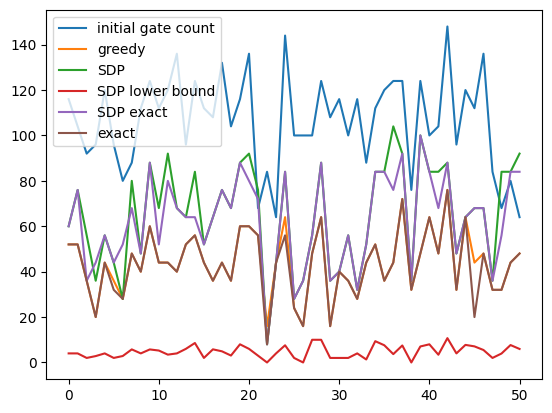

In [90]:
plt.plot(init_cost_list, label="initial gate count")
plt.plot(greedy_opt_list, label="greedy")
plt.plot(sdp_opt_list, label="SDP")
plt.plot(sdp_LB_list, label="SDP lower bound")
plt.plot(sdp_exact_list, label="SDP exact")
plt.plot(exact_list, label="exact")
plt.legend()
plt.show()

## Plot n4

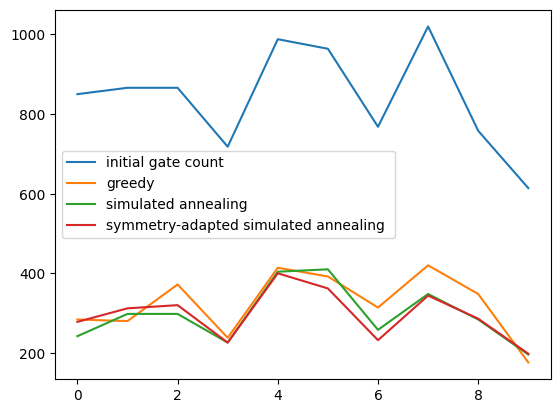

In [31]:
import matplotlib.pyplot as plt

greedy_dict_n4 = load_dict(Path("greedy_dict_n4"))
SA_dict_n4 = load_dict(Path("simulated_annealing_dict_n4"))
SA_CP_dict_n4 = load_dict(Path("simulated_annealing_canon_perm_dict_n4"))

greedy_opt_list = []
SA_opt_list = []
SA_CP_opt_list = []
init_cost_list = []

for key, _ in SA_CP_dict_n4.items():
    
    init_cost = SA_CP_dict_n4[key][0][0]
    init_cost_list.append(init_cost)
    
    greedy_results = greedy_dict_n4[key]
    greedy_opt = np.min([val[2] for val in greedy_results])
    greedy_opt_list.append(greedy_opt)
    
    SA_results = SA_dict_n4[key]
    SA_opt = np.min([val[2] for val in SA_results])
    SA_opt_list.append(SA_opt)
    
    SA_CP_results = SA_CP_dict_n4[key]
    SA_CP_opt = np.min([val[2] for val in SA_CP_results])
    SA_CP_opt_list.append(SA_CP_opt)
    
plt.plot(init_cost_list, label="initial gate count")
plt.plot(greedy_opt_list, label="greedy")
plt.plot(SA_opt_list, label="simulated annealing")
plt.plot(SA_CP_opt_list, label="symmetry-adapted simulated annealing ")
plt.legend()
plt.show()

## Lattice

In [33]:
print(periodic)
print(non_periodic)

[8.0, 36.0, 116.0, 292.0, 740.0, 1796.0]
[12.0, 52.0, 196.0, 516.0, 1284.0, 3076.0]


In [34]:
#G_path = Path("greedy_lattice_dict")
SA_path = Path("simulated_annealing_lattice_dict")
SA_CP_path = Path("simulated_annealing_canon_perm_lattice_dict")

#G_dict = load_dict(G_path, default_factory=list)
SA_dict = load_dict(SA_path, default_factory=list)
SA_CP_dict = load_dict(SA_CP_path, default_factory=list)

for n in [6,7,8]:
    for p in [True, False]:

        H = lattice_adjacency((2**n,), periodic=p)
        obj = lambda X: estimate_h2_trotter_cost(X)["per_step"]["native_2q"]
        init_val = obj(H)
        key = H.tobytes()

        #G_P, G_perm, G_val = fast_greedy_minimize_perm(H, obj)
        #G_dict[key].append((p, init_val, G_perm, G_val))
        #save_dict(G_dict, G_path)
        
        max_iters = 50000
        SA_P, SA_perm, SA_val = simulated_annealing_permutation(H, obj, max_iters=max_iters)
        '''
        SA_dict[key].append({"periodic":p, 
                             "max_iters":max_iters, 
                             "init_val":init_val, 
                             "SA_perm":SA_perm, 
                             "SA_val":SA_val})
        save_dict(SA_dict, SA_path)
        '''
        
        max_iters = 50000
        SA_CP_P, SA_CP_perm, SA_CP_val = simulated_annealing_canon_perm(H, obj, max_iters=max_iters)
        '''
        SA_CP_dict[key].append({"periodic":p, 
                                "max_iters":max_iters, 
                                "init_val":init_val, 
                                "SA_CP_perm":SA_CP_perm, 
                                "SA_CP_val":SA_CP_val})
        save_dict(SA_CP_dict, SA_CP_path)
        '''

SA over permutations:   0%|          | 0/50000 [00:00<?, ?it/s]

[]


SA over permutations:   0%|          | 0/50000 [00:00<?, ?it/s]

SA over permutations:   0%|          | 0/50000 [00:00<?, ?it/s]

[]


...

SA over permutations:   0%|          | 0/50000 [00:00<?, ?it/s]

SA over permutations:   0%|          | 0/50000 [00:00<?, ?it/s]

[]


SA over permutations:   0%|          | 0/50000 [00:00<?, ?it/s]

KeyboardInterrupt: 

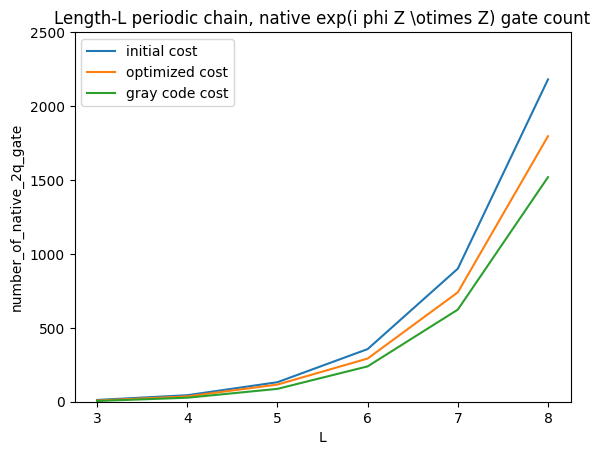

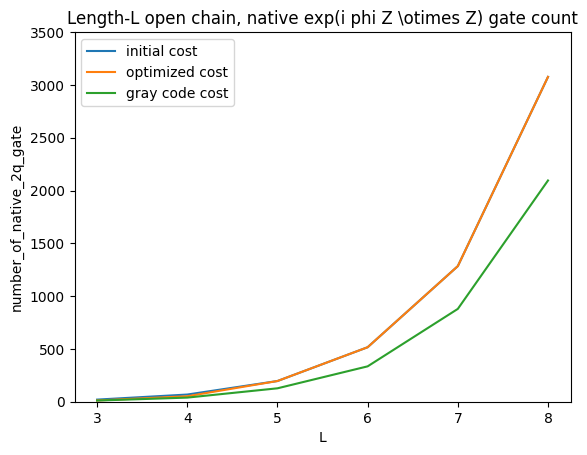

In [32]:
import matplotlib.pyplot as plt

#G_path = Path("greedy_lattice_dict")
SA_path = Path("simulated_annealing_lattice_dict")
SA_CP_path = Path("simulated_annealing_canon_perm_lattice_dict")

#G_dict = load_dict(G_path, default_factory=list)
SA_dict = load_dict(SA_path, default_factory=list)
SA_CP_dict = load_dict(SA_CP_path, default_factory=list)

p_init = []
np_init = []
periodic = []
non_periodic = []

gray_p = []
gray_np = []


xaxis = [3,4,5,6,7,8]
for i, (key, results) in enumerate(sorted(SA_CP_dict.items(), reverse=True)):
    i = i//2
    if results[0]["periodic"] == True:
        p_init.append(results[0]["init_val"])
        val1 = results[0]["SA_CP_val"]
        if len(SA_dict[key]) > 0:
            val2 = SA_dict[key][0]["SA_val"]
            periodic.append(min(val1, val2))
        else:
            periodic.append(val1)
        gray_H = lattice_adjacency((2**xaxis[i],), gray_permute=True, periodic=True)
        gray_p.append(estimate_h2_trotter_cost(gray_H)["per_step"]["native_2q"])
    else:
        np_init.append(results[0]["init_val"])
        val1 = results[0]["SA_CP_val"]
        if len(SA_dict[key]) > 0:
            val2 = SA_dict[key][0]["SA_val"]
            non_periodic.append(min(val1, val2))
        else:
            non_periodic.append(val1)
        gray_H = lattice_adjacency((2**xaxis[i],), gray_permute=True, periodic=False)
        gray_np.append(estimate_h2_trotter_cost(gray_H)["per_step"]["native_2q"])

plt.title("Length-L periodic chain, native exp(i phi Z \otimes Z) gate count")
plt.plot(xaxis, np.array(p_init), label="initial cost")
plt.plot(xaxis, np.array(periodic), label="optimized cost")
plt.plot(xaxis, np.array(gray_p), label="gray code cost")
#plt.yscale("log")
plt.xlabel("L")
plt.ylabel("number_of_native_2q_gate")
plt.ylim((0, 2500))
plt.legend()
plt.show()

plt.title("Length-L open chain, native exp(i phi Z \otimes Z) gate count")
plt.plot(xaxis, np.array(np_init), label="initial cost")
plt.plot(xaxis, np.array(non_periodic), label="optimized cost")
plt.plot(xaxis, np.array(gray_np), label="gray code cost")
#plt.yscale("log")
plt.xlabel("L")
plt.ylabel("number_of_native_2q_gate")
plt.ylim((0, 3500))
plt.legend()
plt.show()